# Parsing and Analyzing Mutation Results

This notebook parses raw experiment outputs and produces the tables and figures used in the paper. Inputs include HttpMutator metric CSVs, PITEST text reports, and aggregated RQ3 summaries under `expScripts/` and `httpmutator-rq3/`. Outputs are CSV and LaTeX tables plus Matplotlib figures written to `exp-analysis-tables-figures/`. The workflow loads metrics, normalizes naming, aggregates per RQ, and exports publication-ready artifacts.


## Index
- [1. Setup and conventions](#1-setup-and-conventions)
- [2. Load HttpMutator metrics](#2-load-httpmutator-metrics)
  - [2.1 df_metrics schema](#21-df_metrics-schema)
- [3. RQ1: Test suite analysis (Table 3)](#3-rq1-test-suite-analysis-table-3)
  - [3.1 Build Table 3 inputs and export](#31-build-table-3-inputs-and-export)
- [4. RQ1: Effectiveness and performance](#4-rq1-effectiveness-and-performance)
  - [4.1 Table 4: Mutation counts and execution time](#41-table-4-mutation-counts-and-execution-time)
  - [4.2 Load operator-usage summaries](#42-load-operator-usage-summaries)
  - [4.3 Aggregate operator counts for Figure 2](#43-aggregate-operator-counts-for-figure-2)
  - [4.4 Figure 2: Operator usage plot](#44-figure-2-operator-usage-plot)
  - [4.5 Table V: Mutants per operator](#45-table-v-mutants-per-operator)
- [5. RQ2: Test adequacy](#5-rq2-test-adequacy)
  - [5.1 Extract TCL 6 test-case counts](#51-extract-tcl-6-test-case-counts)
  - [5.2 PITEST report parser](#52-pitest-report-parser)
  - [5.3 Load PITEST reports (TCL 6)](#53-load-pitest-reports-tcl-6)
  - [5.4 Derive PITEST coverage/time metrics](#54-derive-pitest-coverage-time-metrics)
  - [5.5 Reload HttpMutator metrics by oracle level (TCL 6)](#55-reload-httpmutator-metrics-by-oracle-level-tcl-6)
  - [5.6 Build Table 6](#56-build-table-6)
  - [5.7 Figure 3: Correlation plots](#57-figure-3-correlation-plots)
  - [5.8 Time cost summary by oracle](#58-time-cost-summary-by-oracle)
  - [5.9 Time cost summary helpers](#59-time-cost-summary-helpers)
  - [5.10 Time cost validation checks](#510-time-cost-validation-checks)
- [6. RQ3: Fault detection](#6-rq3-fault-detection)
  - [6.1 Manual fault list: EvoMaster](#61-manual-fault-list-evomaster)
  - [6.2 Manual fault list: Schemathesis](#62-manual-fault-list-schemathesis)
  - [6.3 Build the combined RQ3 table](#63-build-the-combined-rq3-table)
  - [6.4 Format and export RQ3 outputs](#64-format-and-export-rq3-outputs)


## 1. Setup and conventions

This section defines the shared constants, naming conventions, and mappings used across all RQs, as well as the Matplotlib configuration for paper-ready figures.


In [1]:


OUTPUT_DIR = "exp-analysis-tables-figures"


TOOL_NAME_MAPPER = {
    "black": r"\textsc{HttpMutator}",
    "black_random": r"\textsc{HttpMutator-Random}",
    "white": r"\textsc{Pitest}"
}


MUTATOR_MAPPER = {
    "Status Code": {
        "R2XX": ["StatusCodeMutator:StatusCodeReplacementWith20XOperator"],
        "R4XX": ["StatusCodeMutator:StatusCodeReplacementWith40XOperator"],
        "R5XX": ["StatusCodeMutator:StatusCodeReplacementWith50XOperator"]
    },
    "Headers": {
        "CTC": ["MediaTypeMutator:MediaTypeReplacementOperator"],
        "CTD": ["MediaTypeMutator:NullOperator"],
        "CPC": ["CharsetMutator:CharsetReplacementOperator"],
        "CPD": ["CharsetMutator:NullOperator"],
        "LHC": ["LocationMutator:LocationMutationOperator"],
        "LHD": ["LocationMutator:NullOperator"]
    },
    "JSON Payload": {
        "AEA": ["ArrayMutator:ArrayAddElementOperator"],
        "AER": ["ArrayMutator:ArrayRemoveElementOperator"],
        "AEE": ["ArrayMutator:ArrayDisorderElementsOperator"],
        "EAS": ["ArrayMutator:ArrayEmptyOperator"],

        "OPA": ["ObjectMutator:ObjectAddElementOperator"],
        "OPR": ["ObjectMutator:ObjectRemoveElementOperator"],
        "OTPR": ["ObjectMutator:ObjectRemoveObjectTypeElementOperator"],

        "PTC": [
            "ArrayMutator:ChangeTypeOperator",
            "ObjectMutator:ChangeTypeOperator",
            "BooleanMutator:ChangeTypeOperator",
            "DoubleMutator:ChangeTypeOperator",
            "LongMutator:ChangeTypeOperator",
            "StringMutator:ChangeTypeOperator",
            "NullMutator:ChangeTypeOperator"
        ],

        "BPR": ["BooleanMutator:BooleanMutationOperator"],

        "NPS": [
            "ArrayMutator:NullOperator",
            "ObjectMutator:NullOperator",
            "BooleanMutator:NullOperator",
            "DoubleMutator:NullOperator",
            "LongMutator:NullOperator",
            "StringMutator:NullOperator",
        ],

        "NPR": ["DoubleMutator:DoubleReplacementOperator", "LongMutator:LongReplacementOperator"],

        "SCA": ["StringMutator:StringAddSpecialCharactersMutationOperator"],
        "SPR": ["StringMutator:StringReplacementOperator"],
        "SRE": ["StringMutator:StringBoundaryOperator"]
    }
}


MUTATOR_ORDER = [
    "R2XX", "R4XX", "R5XX",

    "CTC", "CTD", "CPC", "CPD", "LHC", "LHD",

    "AEA", "AER", "AEE", "EAS",
    "OPA", "OPR", "OTPR",
    "PTC", "BPR", "NPS", "NPR",
    "SCA", "SPR", "SRE"
]


OP_NAME_MAPPER = {
    "scout-api": {
        "postapiv1activities": "ScoutAPI-CA",
    },
    "project-tracking-system": {
        "postappapiassignments": "ProjectSwagger-AT",
    },
    "user-management": {
        "putusersid": "UserOpenAPI-UU",
        "putusers{id}": "UserOpenAPI-UU",  # same operation, different id formatting
    },
    "market": {
        "postregister": "Market-CU",
    },
    "person-controller": {
        "postapiperson": "PersonOpenAPI-CP",
    },
    "proxyprint": {
        "postrequestregister": "ProxyPrint-CR",
    },
    "languagetool": {
        "postcheck": "LanguageTool-CT",
    },
    "catwatch": {
        "getprojects": "CatWatch-LP",
    },
    "gestaohospital": {
        "postv1hospitais": "GestaoHospital-CH",
        "postHospital": "GestaoHospital-CH",
    },
    "genome-nexus": {
        "postannotation": "GenomeNexus-LA",
    },
    "stripe": {
        "postv1products": "Stripe-CP",
    },
    "foursquare": {
        "getplacessearch": "Foursquare-SP",
    },
    "yelp": {
        "getbusinessessearch": "Yelp-SB",
    },
    "amadeus": {
        "getv3shoppinghotel-offers": "AmadeusHotel-LO",
    },
    "youtube-ind": {
        "getyoutubev3videos": "YouTube-GV",
    },
    "dhl": {
        "getlocation-finderv1find-by-address": "DHL-SL",
    },
    "fdic": {
        "getinstitutions": "FDIC-SI",
    },
    "ohsome": {
        "getelementsaggregation": "Ohsome-GM",
    },
    "deutschebahn": {
        "getstations": "DeutscheBahn-LS",
    },
    "itunes": {
        "getsearch": "iTunes-SM",
    },
}


FORMAL_NAMES = [
    "ScoutAPI-CA",
    "ProjectSwagger-AT",
    "UserOpenAPI-UU",
    "Market-CU",
    "PersonOpenAPI-CP",
    "ProxyPrint-CR",
    "LanguageTool-CT",
    "CatWatch-LP",
    "GestaoHospital-CH",
    "GenomeNexus-LA",
    "Stripe-CP",
    "Foursquare-SP",
    "Yelp-SB",
    "AmadeusHotel-LO",
    "YouTube-GV",
    "DHL-SL",
    "FDIC-SI",
    "Ohsome-GM",
    "DeutscheBahn-LS",
    "iTunes-SM",
]


ORACLE_MAPPER = {
    "5xx": "CR",
    "OAS": "SC",
    "INV": "INV",
    "REG": "RG",
    "FIVE_XX": "CR",
    "INVARIANT": "INV",
    "REGRESSION": "REG"
}


STRENGTH_MAPPER = {
    "one-way-reduced": "TCL 4",
    "one-way": "TCL 5",
    "two-way": "TCL 6",
    "ONE_WAY_REDUCED": "TCL 4",
    "ONE_WAY": "TCL 5",
    "TWO_WAY": "TCL 6"
}


import shutil
import matplotlib.pyplot as plt
import numpy as np


def has_latex():
    """
    Check whether a LaTeX executable is available in the system PATH.
    We test both 'latex' and 'pdflatex' to cover common installations.
    """
    return (
        shutil.which("latex") is not None
        or shutil.which("pdflatex") is not None
    )


USE_TEX = has_latex()

if USE_TEX:
    print("[INFO] LaTeX detected. Using LaTeX for Matplotlib text rendering.")
else:
    print("[INFO] LaTeX not detected. Falling back to Matplotlib text rendering.")


plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,

    "text.usetex": USE_TEX,

    "font.family": "serif",
    "font.serif": ["Palatino Linotype", "Palatino", "Times New Roman"],

    "axes.unicode_minus": False,
})


[INFO] LaTeX detected. Using LaTeX for Matplotlib text rendering.


## 2. Load HttpMutator metrics

This section loads black-box HttpMutator metrics for exhaustive and random strategies into a single DataFrame used throughout the notebook.


In [2]:
from pathlib import Path
import pandas as pd



METRICS_FILENAME_TEMPLATE = "metrics-5xx-{strength_key}.csv"

MODE_TO_DIR = {
    "black": Path("black_metrics"),
    "black_random": Path("black_random_metrics"),
}

STRENGTH_KEYS = list(STRENGTH_MAPPER.keys())

METRICS_UNIQUE_KEYS = ["formal_name", "strength", "mode"]


def load_blackbox_metrics(op_name_mapper: dict) -> pd.DataFrame:
    """
    Load per-operation metrics for black-box modes (black and black_random).

    Expected directory structure:
        {mode_dir}/{api}/{op}/metrics-5xx-{strength_key}.csv

    Output columns (added by this loader):
        - formal_name: canonical operation id used in the paper
        - strength: canonical strength label (e.g., "TCL 4")
        - mode: "black" or "black_random"
        - source_file: absolute/relative path for debugging reproducibility issues
    """
    dfs = []

    for mode, base_dir in MODE_TO_DIR.items():
        for api, api_ops in op_name_mapper.items():
            for op, formal_name in api_ops.items():
                op_dir = base_dir / api / op
                if not op_dir.exists():
                    continue

                for strength_key in STRENGTH_KEYS:
                    metric_file = op_dir / METRICS_FILENAME_TEMPLATE.format(
                        strength_key=strength_key
                    )
                    if not metric_file.exists():
                        continue

                    try:
                        df_one = pd.read_csv(metric_file)
                    except Exception as e:
                        raise RuntimeError(f"Failed to read {metric_file}: {e}") from e

                    df_one = df_one.copy()
                    df_one["formal_name"] = formal_name
                    df_one["strength"] = STRENGTH_MAPPER.get(strength_key, strength_key)
                    df_one["mode"] = mode
                    df_one["source_file"] = str(metric_file)

                    dfs.append(df_one)

    if not dfs:
        raise RuntimeError(
            "No metrics files found.\n"
            f"Checked mode directories: {list(MODE_TO_DIR.values())}\n"
            f"Strength keys: {STRENGTH_KEYS}\n"
            "Please confirm the replication package layout and filenames."
        )

    df_metrics = pd.concat(dfs, ignore_index=True)

    dup_mask = df_metrics.duplicated(subset=METRICS_UNIQUE_KEYS, keep=False)
    if dup_mask.any():
        dups = (
            df_metrics.loc[dup_mask, METRICS_UNIQUE_KEYS + ["source_file"]]
            .sort_values(METRICS_UNIQUE_KEYS)
        )
        display(dups)
        raise ValueError(
            f"Found duplicate rows based on {METRICS_UNIQUE_KEYS}. "
            "See displayed duplicates (with source_file) to locate the cause."
        )

    return df_metrics


df_metrics = load_blackbox_metrics(OP_NAME_MAPPER)

display(df_metrics.head(20))
print(f"[INFO] Loaded df_metrics with shape={df_metrics.shape} "
      f"from {df_metrics['source_file'].nunique()} files.")


,tc_count,resp_fields_count,total,passed,kill_rate,time_cost,formal_name,strength,mode,source_file
0,4,170,644,640,0.6,0.82,ScoutAPI-CA,TCL 4,black,black_metrics/scout-api/postapiv1activities/me...
1,6,226,853,847,0.7,0.89,ScoutAPI-CA,TCL 5,black,black_metrics/scout-api/postapiv1activities/me...
2,31,1521,5761,5730,0.5,1.27,ScoutAPI-CA,TCL 6,black,black_metrics/scout-api/postapiv1activities/me...
3,2,67,275,273,0.7,0.48,ProjectSwagger-AT,TCL 4,black,black_metrics/project-tracking-system/postappa...
4,9,331,1331,1322,0.7,0.59,ProjectSwagger-AT,TCL 5,black,black_metrics/project-tracking-system/postappa...
5,44,1926,7753,7709,0.6,1.01,ProjectSwagger-AT,TCL 6,black,black_metrics/project-tracking-system/postappa...
6,3,68,261,258,1.1,0.42,UserOpenAPI-UU,TCL 4,black,black_metrics/user-management/putusersid/metri...
7,10,266,1058,1048,0.9,0.56,UserOpenAPI-UU,TCL 5,black,black_metrics/user-management/putusersid/metri...
8,52,1622,6526,6474,0.8,1.12,UserOpenAPI-UU,TCL 6,black,black_metrics/user-management/putusersid/metri...
9,2,21,86,84,2.3,0.26,Market-CU,TCL 4,black,black_metrics/market/postregister/metrics-5xx-...


[INFO] Loaded df_metrics with shape=(120, 10) from 120 files.


### 2.1 df_metrics schema

The following cell lists the columns available in `df_metrics` and serves as a quick reference for downstream tables.


In [3]:
df_metrics.columns

Index(['tc_count', 'resp_fields_count', 'total', 'passed', 'kill_rate',
       'time_cost', 'formal_name', 'strength', 'mode', 'source_file'],
      dtype='object')

## 3. RQ0: Test suite analysis (Table 3)

This section derives Table 3, which summarizes test suite size and response-field counts for the exhaustive HttpMutator configuration. The output is saved as a CSV for downstream use.


### 3.1 Build Table 3 inputs and export

The next cell filters the exhaustive configuration, maps strength to suite size, enforces ordering, and exports Table 3.


In [4]:

t3_src = (
    df_metrics.loc[
        df_metrics["mode"].eq("black"),
        ["formal_name", "strength", "tc_count", "resp_fields_count"]
    ]
    .copy()
)

STRENGTH_TO_SUITE = {
    "TCL 4": "Small",
    "TCL 5": "Medium",
    "TCL 6": "Large",
}

t3_src["suite"] = t3_src["strength"].map(STRENGTH_TO_SUITE)

if t3_src["suite"].isna().any():
    bad = (
        t3_src.loc[t3_src["suite"].isna(), ["formal_name", "strength"]]
        .drop_duplicates()
    )
    raise ValueError(
        "Unexpected strength values when building Table 3:\n"
        f"{bad}"
    )

dup = t3_src.duplicated(subset=["formal_name", "suite"], keep=False)
if dup.any():
    raise ValueError(
        "Duplicate (formal_name, suite) rows detected in df_metrics "
        "for mode == 'black'. Table 3 requires exactly one."
    )

table3 = (
    t3_src
    .pivot_table(
        index="formal_name",
        columns="suite",
        values=["tc_count", "resp_fields_count"],
        aggfunc="first"
    )
)

ordered_cols = [
    ("tc_count", "Small"),
    ("resp_fields_count", "Small"),
    ("tc_count", "Medium"),
    ("resp_fields_count", "Medium"),
    ("tc_count", "Large"),
    ("resp_fields_count", "Large"),
]

table3 = table3.loc[:, [c for c in ordered_cols if c in table3.columns]]

table3.columns = [
    "Small_#TC", "Small_#RF",
    "Medium_#TC", "Medium_#RF",
    "Large_#TC", "Large_#RF",
][:len(table3.columns)]

table3 = table3.reindex(FORMAL_NAMES)

missing_apis = table3.index[table3.isna().all(axis=1)]
if len(missing_apis) > 0:
    print(
        "[WARN][Table 3] The following APIs have no data and will appear empty:\n",
        list(missing_apis)
    )

total_row = table3.sum(numeric_only=True)
total_row.name = "Total"
table3 = pd.concat([table3, total_row.to_frame().T])

table3_display = table3.copy()
for col in table3_display.columns:
    table3_display[col] = table3_display[col].apply(
        lambda x: f"{int(x):,}" if pd.notna(x) else x
    )

display(table3_display)

OUTPUT_DIR = Path(OUTPUT_DIR) 
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

csv_path = OUTPUT_DIR / "table3_tc_rf.csv"
table3.to_csv(csv_path, index=True)

print(f"[OK] Table 3 saved to CSV: {csv_path}")

,Small_#TC,Small_#RF,Medium_#TC,Medium_#RF,Large_#TC,Large_#RF
ScoutAPI-CA,4,170,6,226,31,"1,521"
ProjectSwagger-AT,2,67,9,331,44,"1,926"
UserOpenAPI-UU,3,68,10,266,52,"1,622"
Market-CU,2,21,4,43,15,164
PersonOpenAPI-CP,2,35,4,69,35,587
ProxyPrint-CR,2,22,7,92,28,386
LanguageTool-CT,4,91,6,133,30,"1,117"
CatWatch-LP,2,11,15,140,155,"1,298"
GestaoHospital-CH,2,16,5,43,19,169
GenomeNexus-LA,2,"1,159",9,"5,421",41,"27,562"


[OK] Table 3 saved to CSV: exp-analysis-tables-figures/table3_tc_rf.csv


## 4. RQ1: Effectiveness and performance

This section builds the RQ1 tables and figures based on HttpMutator metrics, including mutation counts, execution time, operator usage, and operator-level totals.


### 4.1 Table 4: Mutation counts and execution time

This cell aggregates mutation counts and time costs across strengths and strategies and exports the Table 4 CSV and LaTeX.


In [5]:
from pathlib import Path
import pandas as pd


SUITE_LABEL = {  # strength -> paper suite header
    "TCL 4": "Small",
    "TCL 5": "Medium",
    "TCL 6": "Large",
}

MODE_LABEL = {   # mode -> paper strategy header
    "black": "Exhaustive",
    "black_random": "Random",
}

df_rq1 = df_metrics.copy()

df_rq1["Suite"] = df_rq1["strength"].map(SUITE_LABEL)
df_rq1["Strategy"] = df_rq1["mode"].map(MODE_LABEL)

df_rq1 = df_rq1[[
    "formal_name",
    "Suite",
    "Strategy",
    "total",      # total mutants
    "time_cost",  # total time in seconds
]].copy()

df_rq1 = df_rq1.dropna(subset=["Suite", "Strategy"])

key_cols = ["formal_name", "Suite", "Strategy"]
dup_mask = df_rq1.duplicated(subset=key_cols, keep=False)
if dup_mask.any():
    dups = df_rq1.loc[dup_mask, key_cols + ["total", "time_cost"]].sort_values(key_cols)
    display(dups)
    raise ValueError(f"Duplicate entries found for {key_cols}. "
                     "Please ensure each configuration is reported once.")

pivot_numeric = df_rq1.pivot_table(
    index="formal_name",
    columns=["Suite", "Strategy"],
    values=["total", "time_cost"],
    aggfunc="sum"  # safe even if there is exactly one row
)

pivot_numeric.columns = pivot_numeric.columns.set_names(["Metric", "Suite", "Strategy"])
pivot_numeric = pivot_numeric.rename(
    columns={"total": "#M", "time_cost": "Time (s)"},
    level="Metric"
)

pivot_numeric = pivot_numeric.reorder_levels(["Suite", "Strategy", "Metric"], axis=1)

suite_order = ["Small", "Medium", "Large"]
strategy_order = ["Exhaustive", "Random"]
metric_order = ["#M", "Time (s)"]

pivot_numeric = pivot_numeric.reindex(
    columns=pd.MultiIndex.from_product([suite_order, strategy_order, metric_order])
)

pivot_numeric = pivot_numeric.reindex(FORMAL_NAMES)

pivot_numeric.loc["Total"] = pivot_numeric.sum(numeric_only=True)

# ===========================
# Δ(Random vs Exhaustive) per-API, then averaged across APIs
# ===========================

def _safe_abs_reduction(exhaustive: float, random: float):
    """
    Absolute reduction per API:
      Exhaustive - Random
    """
    if pd.isna(exhaustive) or pd.isna(random):
        return pd.NA
    return exhaustive - random


def _safe_pct_reduction(exhaustive: float, random: float):
    """
    Percentage reduction per API:
      (Exhaustive - Random) / Exhaustive * 100
    Returns NA if Exhaustive is zero or missing.
    """
    if pd.isna(exhaustive) or pd.isna(random) or exhaustive == 0:
        return pd.NA
    return (exhaustive - random) / exhaustive * 100.0


# Exclude the aggregated "Total" row if it exists
api_rows = [r for r in pivot_numeric.index if r != "Total"]

print("\n[INFO] Random vs Exhaustive reductions (computed per API, then averaged):")

for suite in ["Small", "Medium", "Large"]:
    # Extract per-API values
    ex_m = pivot_numeric.loc[api_rows, (suite, "Exhaustive", "#M")]
    rd_m = pivot_numeric.loc[api_rows, (suite, "Random", "#M")]
    ex_t = pivot_numeric.loc[api_rows, (suite, "Exhaustive", "Time (s)")]
    rd_t = pivot_numeric.loc[api_rows, (suite, "Random", "Time (s)")]

    # Per-API absolute reductions
    m_abs = ex_m - rd_m
    t_abs = ex_t - rd_t

    # Per-API percentage reductions
    m_pct = (m_abs / ex_m) * 100.0
    t_pct = (t_abs / ex_t) * 100.0

    # Guard against division by zero and invalid values
    m_pct = m_pct.where(ex_m != 0)
    t_pct = t_pct.where(ex_t != 0)
    m_pct = m_pct.replace([float("inf"), float("-inf")], pd.NA)
    t_pct = t_pct.replace([float("inf"), float("-inf")], pd.NA)

    # Average across APIs (each API contributes equally)
    m_abs_mean = m_abs.mean(skipna=True)
    t_abs_mean = t_abs.mean(skipna=True)
    m_pct_mean = m_pct.mean(skipna=True)
    t_pct_mean = t_pct.mean(skipna=True)

    # Format for printing
    m_abs_str = "--" if pd.isna(m_abs_mean) else f"{int(round(m_abs_mean)):,}"
    t_abs_str = "--" if pd.isna(t_abs_mean) else f"{t_abs_mean:,.2f}"
    m_pct_str = "--" if pd.isna(m_pct_mean) else f"{m_pct_mean:.2f}%"
    t_pct_str = "--" if pd.isna(t_pct_mean) else f"{t_pct_mean:.2f}%"

    print(
        f"  - {suite}: "
        f"avg #M reduction = {m_abs_str} ({m_pct_str}); "
        f"avg Time reduction = {t_abs_str} ({t_pct_str})"
    )

print()


pivot_fmt = pivot_numeric.copy()

for col in pivot_fmt.columns:
    if col[2] == "#M":
        pivot_fmt[col] = pivot_fmt[col].apply(
            lambda x: f"{int(x):,}" if pd.notna(x) else "--"
        )
    elif col[2] == "Time (s)":
        pivot_fmt[col] = pivot_fmt[col].apply(
            lambda x: f"{float(x):,.2f}" if pd.notna(x) else "--"
        )

out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

pivot_fmt.to_csv(out_dir / "RQ1-TableIV-mutation_counts_time.csv", encoding="utf-8", index=True)

latex_str = pivot_fmt.to_latex(
    multirow=True,
    multicolumn=True,
    escape=True,   # safe since we no longer include $...$ in headers
    index=True,
    na_rep="--",
    longtable=False
)

with open(out_dir / "RQ1-TableIV-mutation_counts_time.tex", "w", encoding="utf-8") as f:
    f.write(latex_str)

display(pivot_numeric)
print(f"[INFO] Exported Table IV CSV/TEX to: {out_dir}")



[INFO] Random vs Exhaustive reductions (computed per API, then averaged):
  - Small: avg #M reduction = 2,436 (73.49%); avg Time reduction = 3.17 (16.62%)
  - Medium: avg #M reduction = 9,997 (74.40%); avg Time reduction = 7.42 (30.23%)
  - Large: avg #M reduction = 156,520 (74.58%); avg Time reduction = 177.54 (38.63%)



Small                                Medium           \
                  Exhaustive            Random          Exhaustive            
                          #M Time (s)       #M Time (s)         #M Time (s)   
formal_name                                                                   
ScoutAPI-CA            644.0     0.82    174.0     0.83      853.0     0.89   
ProjectSwagger-AT      275.0     0.48     69.0     0.31     1331.0     0.59   
UserOpenAPI-UU         261.0     0.42     71.0     0.35     1058.0     0.56   
Market-CU               86.0     0.26     23.0     0.22      176.0     0.26   
PersonOpenAPI-CP       127.0     0.35     37.0     0.33      253.0     0.40   
ProxyPrint-CR           90.0     0.70     24.0     0.69      376.0     0.80   
LanguageTool-CT        369.0     1.12     94.0     1.03      533.0     1.12   
CatWatch-LP             40.0     0.59     13.0     0.60      392.0     0.71   
GestaoHospital-CH       62.0     0.33     18.0     0.31      167.0     0.37   
GenomeNexus-LA        5305.0     3.59   1160.0     1.50    24680.0     9.77   
Stripe-CP              552.0     0.70    135.0     0.61     2692.0     0.94   
Foursquare-SP         1410.0     0.96    307.0     0.72     1791.0     1.00   
Yelp-SB                 83.0     0.60     27.0     0.59     9377.0     3.25   
AmadeusHotel-LO       4370.0     2.76    943.0     1.43     6596.0     3.10   
YouTube-GV             568.0     0.74    132.0     0.65    53010.0    42.95   
DHL-SL                  32.0     0.64     12.0     0.59    27862.0    11.42   
FDIC-SI                144.0     0.59     36.0     0.58     3895.0     1.08   
Ohsome-GM              175.0     0.61     48.0     0.62      473.0     0.66   
DeutscheBahn-LS      48176.0    97.74  11621.0    38.81    63956.0   111.26   
iTunes-SM             1132.0     0.88    247.0     0.70    59211.0    47.29   
Total                63901.0   114.88  15191.0    51.47   258682.0   238.42   

                                         Large                              
                    Random          Exhaustive             Random           
                        #M Time (s)         #M Time (s)        #M Time (s)  
formal_name                                                                 
ScoutAPI-CA          232.0     0.80     5761.0     1.27    1552.0     1.04  
ProjectSwagger-AT    339.0     0.46     7753.0     1.01    1969.0     0.77  
UserOpenAPI-UU       276.0     0.43     6526.0     1.12    1674.0     0.77  
Market-CU             47.0     0.24      671.0     0.33     179.0     0.31  
PersonOpenAPI-CP      73.0     0.34     2178.0     0.67     622.0     0.55  
ProxyPrint-CR         99.0     0.73     1570.0     0.99     414.0     0.88  
LanguageTool-CT      138.0     1.06     4626.0     1.43    1146.0     1.26  
CatWatch-LP          155.0     0.69     3551.0     1.19    1453.0     1.12  
GestaoHospital-CH     48.0     0.31      657.0     0.44     188.0     0.41  
GenomeNexus-LA      5429.0     3.31   124870.0    40.29   27602.0    13.87  
Stripe-CP            674.0     0.75    36891.0     2.98    9194.0     1.92  
Foursquare-SP        420.0     0.77    44830.0    15.59   10031.0     6.05  
Yelp-SB             2249.0     1.75   136843.0   102.24   32875.0    38.28  
AmadeusHotel-LO     1435.0     1.59   136136.0   247.11   29372.0    79.86  
YouTube-GV         11710.0    12.52   658872.0   738.49  144879.0   209.99  
DHL-SL              6041.0     4.85   134904.0    64.16   29355.0    23.48  
FDIC-SI              948.0     0.81   316937.0   715.91   73673.0   254.12  
Ohsome-GM            128.0     0.64     2373.0     0.90     636.0     0.80  
DeutscheBahn-LS    15449.0    45.60   361899.0   649.71   87394.0   241.71  
iTunes-SM          12852.0    12.38  2033640.0  2491.51  436890.0   649.37  
Total              58742.0    90.03  4021488.0  5077.34  891098.0  1526.56

[INFO] Exported Table IV CSV/TEX to: exp-analysis-tables-figures


### 4.2 Load operator-usage summaries

This cell loads per-operation operator usage summaries and builds a wide DataFrame for operator-level analysis.


In [6]:
all_ops = sorted({
    op_class
    for code_dict in MUTATOR_MAPPER.values()
    for op_classes in code_dict.values()
    for op_class in op_classes
})

def load_operator_usage_wide(base_dir: Path, mode: str, all_ops: list[str]) -> pd.DataFrame:
    """
    Load operator-usage summary tables produced per operation.

    File layout:
      {base_dir}/{api}/{op}/operators-{strength_key}.csv

    Each CSV must contain exactly one data row.
    Columns must be a subset of `all_ops` (no exceptions).
    """
    rows = []

    for api, api_ops in OP_NAME_MAPPER.items():
        for op, formal_name in api_ops.items():
            op_dir = base_dir / api / op
            if not op_dir.exists():
                continue

            for strength_key in STRENGTH_MAPPER.keys():
                fpath = op_dir / f"operators-{strength_key}.csv"
                if not fpath.exists():
                    continue

                try:
                    df_one = pd.read_csv(fpath)
                except Exception as e:
                    print(f"[WARN] Failed to read {fpath}: {e}")
                    continue

                if len(df_one) != 1:
                    raise ValueError(
                        f"Expected exactly 1 data row in {fpath}, found {len(df_one)} "
                        f"(api={api}, op={op}, formal_name={formal_name}, mode={mode})"
                    )

                cols = set(df_one.columns)
                extra = cols - set(all_ops)
                if extra:
                    raise ValueError(f"Unexpected operator columns in {fpath}: {sorted(extra)}")

                series = df_one.iloc[0].apply(pd.to_numeric, errors="raise").fillna(0).astype(int)

                record = {
                    "formal_name": formal_name,
                    "strength": STRENGTH_MAPPER.get(strength_key, strength_key),
                    "mode": mode,
                }
                for op_class in all_ops:
                    record[op_class] = int(series.get(op_class, 0))

                rows.append(record)

    if not rows:
        raise RuntimeError(f"No operator files found under: {base_dir}")

    return pd.DataFrame(rows)


df_ops_wide = pd.concat([
    load_operator_usage_wide(Path("black_metrics"), mode="black", all_ops=all_ops),
    load_operator_usage_wide(Path("black_random_metrics"), mode="black_random", all_ops=all_ops),
], ignore_index=True)

display(df_ops_wide.head())
print(f"[INFO] df_ops_wide shape={df_ops_wide.shape}")

,formal_name,strength,mode,ArrayMutator:ArrayAddElementOperator,ArrayMutator:ArrayDisorderElementsOperator,ArrayMutator:ArrayEmptyOperator,ArrayMutator:ArrayRemoveElementOperator,ArrayMutator:ChangeTypeOperator,ArrayMutator:NullOperator,BooleanMutator:BooleanMutationOperator,...,ObjectMutator:ObjectRemoveElementOperator,ObjectMutator:ObjectRemoveObjectTypeElementOperator,StatusCodeMutator:StatusCodeReplacementWith20XOperator,StatusCodeMutator:StatusCodeReplacementWith40XOperator,StatusCodeMutator:StatusCodeReplacementWith50XOperator,StringMutator:ChangeTypeOperator,StringMutator:NullOperator,StringMutator:StringAddSpecialCharactersMutationOperator,StringMutator:StringBoundaryOperator,StringMutator:StringReplacementOperator
0,ScoutAPI-CA,TCL 4,black,15,0,11,0,15,15,4,...,22,7,4,4,4,51,51,51,51,51
1,ScoutAPI-CA,TCL 5,black,20,0,14,0,20,20,6,...,29,10,6,6,6,66,66,66,66,66
2,ScoutAPI-CA,TCL 6,black,135,0,93,0,135,135,38,...,194,71,31,31,31,450,450,450,450,450
3,ProjectSwagger-AT,TCL 4,black,0,0,0,0,0,0,2,...,11,5,2,2,2,34,34,34,34,34
4,ProjectSwagger-AT,TCL 5,black,0,0,0,0,0,0,10,...,52,26,9,9,9,161,161,161,161,161


[INFO] df_ops_wide shape=(120, 38)


### 4.3 Aggregate operator counts for Figure 2

This cell collapses operator-class counts into paper operator codes and prepares the totals used in Figure 2.


In [7]:
FIG_STRENGTH = "TCL 6"  # Large test suite

code_to_group = {}
code_to_opclasses = {}
for group, code_dict in MUTATOR_MAPPER.items():
    for code, op_classes in code_dict.items():
        code_to_group[code] = group
        code_to_opclasses[code] = op_classes

df_large = df_ops_wide[df_ops_wide["strength"] == FIG_STRENGTH].copy()

sum_by_mode = df_large.groupby("mode")[all_ops].sum()

def _code_count(mode: str, code: str) -> int:
    """Total mutants for a given operator code under a given mode."""
    if mode not in sum_by_mode.index:
        return 0
    return int(sum_by_mode.loc[mode, code_to_opclasses[code]].sum())

base_rows = []
for code in MUTATOR_ORDER:
    if code not in code_to_group:
        continue

    exhaustive_count = _code_count("black", code)
    random_count = _code_count("black_random", code)

    if exhaustive_count < 1:
        continue

    base_rows.append({
        "group": code_to_group[code],
        "code": code,

        "exhaustive_count": exhaustive_count,      # HTTPMutator (Exhaustive)
        "random_count": random_count,              # HTTPMutator (Random)
        "exhaustive_only_count": exhaustive_count - random_count,
    })

df_fig2_ops = pd.DataFrame(base_rows)

assert (df_fig2_ops["random_count"] <= df_fig2_ops["exhaustive_count"]).all()
assert (
    df_fig2_ops["exhaustive_only_count"]
    == df_fig2_ops["exhaustive_count"] - df_fig2_ops["random_count"]
).all()

# ===========================
# Share report for counts (Exhaustive vs Random)
# ===========================

TARGET_CODES = {"PTC", "NPS", "SRE", "SPR", "SCA"}
TARGET_GROUPS = ["Status Code", "Headers"]

# Use the dataframe that contains: code, group, exhaustive_count, random_count
# Replace df_fig2_ops with your actual dataframe name if different.
df_ops = df_fig2_ops

def _sum_or_na(s: pd.Series):
    v = s.sum(skipna=True)
    return pd.NA if pd.isna(v) else v

def _share(numer: float, denom: float):
    if pd.isna(numer) or pd.isna(denom) or denom == 0:
        return pd.NA
    return numer / denom

def _fmt_int(x):
    return "--" if pd.isna(x) else f"{int(x):,}"

def _fmt_pct(x):
    return "--" if pd.isna(x) else f"{x * 100:.2f}%"

def _report_block(title: str, ex_n: float, ex_d: float, rd_n: float, rd_d: float):
    ex_share = _share(ex_n, ex_d)
    rd_share = _share(rd_n, rd_d)
    print(f"[INFO] {title}")
    print(f"  Exhaustive: {_fmt_int(ex_n)} / {_fmt_int(ex_d)} = {_fmt_pct(ex_share)}")
    print(f"  Random:     {_fmt_int(rd_n)} / {_fmt_int(rd_d)} = {_fmt_pct(rd_share)}")
    print("")

# Denominators: totals over all operators
ex_total = _sum_or_na(df_ops["exhaustive_count"])
rd_total = _sum_or_na(df_ops["random_count"])

# 1) Codes share
ex_codes = _sum_or_na(df_ops.loc[df_ops["code"].isin(TARGET_CODES), "exhaustive_count"])
rd_codes = _sum_or_na(df_ops.loc[df_ops["code"].isin(TARGET_CODES), "random_count"])
_report_block(
    title=f"Codes in {sorted(TARGET_CODES)}",
    ex_n=ex_codes, ex_d=ex_total,
    rd_n=rd_codes, rd_d=rd_total,
)

# 2) Group shares
for g in TARGET_GROUPS:
    ex_g = _sum_or_na(df_ops.loc[df_ops["group"] == g, "exhaustive_count"])
    rd_g = _sum_or_na(df_ops.loc[df_ops["group"] == g, "random_count"])
    _report_block(
        title=f'Group == "{g}"',
        ex_n=ex_g, ex_d=ex_total,
        rd_n=rd_g, rd_d=rd_total,
    )

display(df_fig2_ops.sort_values("exhaustive_count", ascending=False).head(10))


[INFO] Codes in ['NPS', 'PTC', 'SCA', 'SPR', 'SRE']
  Exhaustive: 3,536,536 / 4,021,488 = 87.94%
  Random:     761,233 / 891,098 = 85.43%

[INFO] Group == "Status Code"
  Exhaustive: 7,077 / 4,021,488 = 0.18%
  Random:     2,359 / 891,098 = 0.26%

[INFO] Group == "Headers"
  Exhaustive: 8,631 / 4,021,488 = 0.21%
  Random:     4,710 / 891,098 = 0.53%



,group,code,exhaustive_count,random_count,exhaustive_only_count
14,JSON Payload,PTC,881674,204686,676988
16,JSON Payload,NPS,879105,202030,677075
20,JSON Payload,SRE,591919,118257,473662
19,JSON Payload,SPR,591919,118244,473675
18,JSON Payload,SCA,591919,118016,473903
17,JSON Payload,NPR,126966,42693,84273
11,JSON Payload,OPA,90005,22104,67901
12,JSON Payload,OPR,87278,20957,66321
7,JSON Payload,AEA,38334,8581,29753
15,JSON Payload,BPR,34236,11310,22926


### 4.4 Figure 2: Operator usage plot

This cell generates the operator usage plot for the Large test suite and saves the figure outputs.


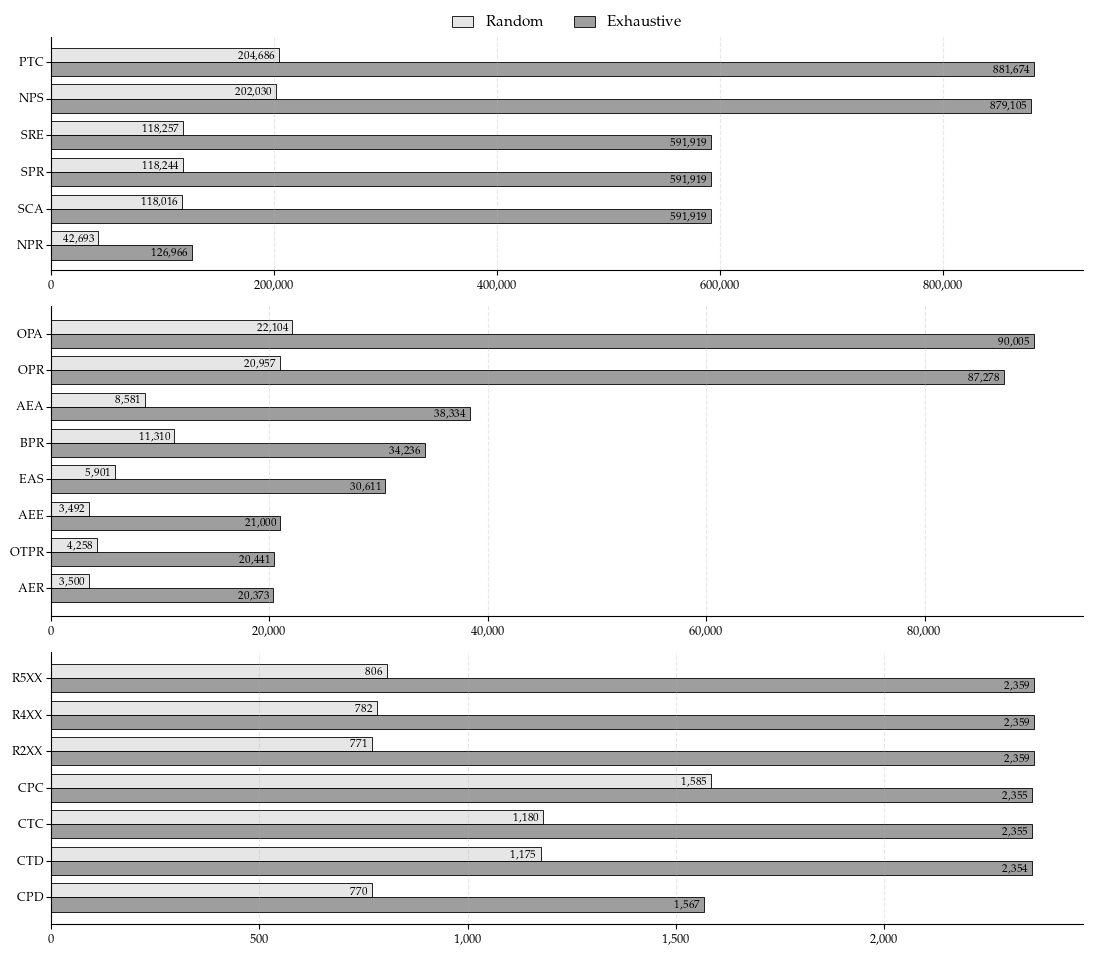

Saved figure to: exp-analysis-tables-figures/RQ1-operator-distribution-3ranges.pdf


In [8]:

from matplotlib.ticker import FuncFormatter
import matplotlib as mpl
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def _detect_tex():
    """
    Detect whether a working LaTeX environment is available for matplotlib.
    """
    try:
        return mpl.rcParams.get("text.usetex", False)
    except Exception:
        return False

HAS_TEX = _detect_tex()

def _label_httpmutator():
    return "Exhaustive"

def _label_hmrd():
    return "Random"


df_fig2_ops_sorted = (
    df_fig2_ops
    .sort_values(["exhaustive_count", "random_count"], ascending=[False, False])
    .reset_index(drop=True)
)

high_df = df_fig2_ops_sorted[df_fig2_ops_sorted["exhaustive_count"] > 120_000].copy()
mid_df  = df_fig2_ops_sorted[
    (df_fig2_ops_sorted["exhaustive_count"] >= 10_000)
    & (df_fig2_ops_sorted["exhaustive_count"] <= 120_000)
].copy()
low_df  = df_fig2_ops_sorted[df_fig2_ops_sorted["exhaustive_count"] < 10_000].copy()

ranges = [
    ("$>$ 120k", high_df),
    ("[10k, 120k]", mid_df),
    ("$<$ 10k", low_df),
]

BAR_HEIGHT = 0.48
sizes = [len(df_) for _, df_ in ranges]
subplot_heights = [max(1.5, BAR_HEIGHT * n) for n in sizes]
total_height = sum(subplot_heights)

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(11, total_height),
    sharex=False,
    gridspec_kw={"height_ratios": subplot_heights},
)

RANDOM_STYLE = dict(
    color="#E6E6E6",      # light gray
    edgecolor="black",
    linewidth=0.6,
)

EXHAUSTIVE_STYLE = dict(
    color="#9E9E9E",      # darker gray
    edgecolor="black",
    linewidth=0.6,
)


for ax, (title_suffix, sub_df) in zip(axes, ranges):
    if sub_df.empty:
        ax.axis("off")
        continue

    sub_df = sub_df.reset_index(drop=True)

    codes = sub_df["code"].tolist()
    random_vals = sub_df["random_count"].to_numpy()
    exhaustive_vals = sub_df["exhaustive_count"].to_numpy()

    Y_GAP = 1.25   # 1.2 ~ 1.5 
    y_pos = np.arange(len(sub_df)) * Y_GAP
    bars_random = ax.barh(
        y_pos - BAR_HEIGHT / 2,
        random_vals,
        height=BAR_HEIGHT,
        label=_label_hmrd(),
        **RANDOM_STYLE,
    )
    bars_exhaustive = ax.barh(
        y_pos + BAR_HEIGHT / 2,
        exhaustive_vals,
        height=BAR_HEIGHT,
        label=_label_httpmutator(),
        **EXHAUSTIVE_STYLE,
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(codes, fontsize=9)
    ax.tick_params(axis="y", pad=2)
    ax.invert_yaxis()

    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_xlim(left=0, right=float(exhaustive_vals.max()) * 1.05)

    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    xmin, xmax = ax.get_xlim()
    offset = 0.005 * (xmax - xmin)

    def add_labels(bar_container, dy_pt=-1.0):
        """
        Add value labels inside horizontal bars with precise vertical alignment.

        Parameters
        ----------
        bar_container : iterable of matplotlib.patches.Rectangle
            The bars returned by ax.barh(...).
        dy_pt : float, default -1.0
            Vertical offset in *points* applied to the text label.
            Negative values move the label slightly downward to compensate
            for font baseline rendering (recommended for PDF/LaTeX figures).
        """
        for rect in bar_container:
            w = rect.get_width()
            if w <= 0:
                continue

            y = rect.get_y() + rect.get_height() / 2

            x = w - offset

            ax.annotate(
                f"{int(w):,}",
                xy=(x, y),
                xytext=(0, dy_pt),           # Offset in points (device-independent)
                textcoords="offset points",  # Use point-based offset for robustness
                va="center",
                ha="right",
                fontsize=8,
                fontweight="bold",
            )

    add_labels(bars_random)
    add_labels(bars_exhaustive)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15), 
    ncol=2,
    frameon=False,
    fontsize=11,
    handlelength=1.4,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "RQ1-operator-distribution-3ranges.pdf"
fig.savefig(output_path, bbox_inches="tight")

names = [
    "RQ1-operator-distribution-high.pdf",
    "RQ1-operator-distribution-mid.pdf",
    "RQ1-operator-distribution-low.pdf",
]

for ax, fname in zip(axes, names):
    bbox = ax.get_tightbbox(fig.canvas.get_renderer())
    bbox_inches = bbox.transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(output_dir / fname, bbox_inches=bbox_inches, dpi=300)

plt.show()
print(f"Saved figure to: {output_path}")


### 4.5 Table V: Mutants per operator

This cell builds Table V by aggregating operator counts and exports the LaTeX subtables per oracle strength.


In [9]:
MODE_FOR_TABLE = "black"  # Table V in the screenshot uses Exhaustive totals
strength_order = ["TCL 4", "TCL 5", "TCL 6"]  # (a)(b)(c)

STATUS_CODE_COLS = ["R2XX", "R4XX", "R5XX"]
HEADER_COLS = ["CTC", "CTD", "CPC", "CPD"]
JSON_COLS = [c for c in MUTATOR_ORDER if c not in STATUS_CODE_COLS + HEADER_COLS]

final_cols = ["Operation"] + MUTATOR_ORDER
num_cols = MUTATOR_ORDER  # numeric columns to sum/format


OPCLASS_TO_CODE = {}
for _, code_dict in MUTATOR_MAPPER.items():
    for code, op_classes in code_dict.items():
        for op_class in op_classes:
            OPCLASS_TO_CODE[op_class] = code

def collapse_ops_wide_to_codes(df_ops_wide: pd.DataFrame, all_ops: list[str]) -> pd.DataFrame:
    """
    Convert operator-class wide table to operator-code wide table.
    Input columns: formal_name, strength, mode, <operator-class columns>
    Output columns: formal_name, strength, mode, <operator-code columns in MUTATOR_ORDER>
    """
    base_cols = ["formal_name", "strength", "mode"]
    df_in = df_ops_wide[base_cols + all_ops].copy()

    out = df_in[base_cols].copy()
    for code in MUTATOR_ORDER:
        out[code] = 0

    for op_class in all_ops:
        code = OPCLASS_TO_CODE.get(op_class)
        if code is None:
            continue
        out[code] = out[code] + df_in[op_class].astype(int)

    return out


df_ops_code = collapse_ops_wide_to_codes(df_ops_wide, all_ops=all_ops)

df_table = (
    df_ops_code[df_ops_code["mode"] == MODE_FOR_TABLE]
    .rename(columns={"formal_name": "Operation"})
    .copy()
)

for m in MUTATOR_ORDER:
    if m not in df_table.columns:
        df_table[m] = 0

df_table["Operation"] = pd.Categorical(df_table["Operation"], categories=FORMAL_NAMES, ordered=True)

df_table["strength"] = pd.Categorical(df_table["strength"], categories=strength_order, ordered=True)

df_table = df_table[["strength"] + final_cols].sort_values(["strength", "Operation"])


def _span(col_names: list[str], col_index: dict[str, int]) -> tuple[int, int]:
    idx = [col_index[c] for c in col_names]
    return min(idx), max(idx)

def build_group_header_latex(final_cols: list[str]) -> str:
    """
    Insert after \\toprule:
      & \\multicolumn{3}{c}{Status Code} & \\multicolumn{4}{c}{Headers} & \\multicolumn{...}{c}{JSON Payload} \\\\
      \\cmidrule(lr){...}...
    """
    col_index = {c: i for i, c in enumerate(final_cols)}  # 0-based

    s0, s1 = _span(STATUS_CODE_COLS, col_index)
    h0, h1 = _span(HEADER_COLS, col_index)
    j0, j1 = _span(JSON_COLS, col_index)

    s0 += 1; s1 += 1
    h0 += 1; h1 += 1
    j0 += 1; j1 += 1

    header = (
        f" & "
        f"\\multicolumn{{{s1-s0+1}}}{{c}}{{Status Code}} & "
        f"\\multicolumn{{{h1-h0+1}}}{{c}}{{Headers}} & "
        f"\\multicolumn{{{j1-j0+1}}}{{c}}{{JSON Payload}} \\\\\n"
        f"\\cmidrule(lr){{{s0}-{s1}}}"
        f"\\cmidrule(lr){{{h0}-{h1}}}"
        f"\\cmidrule(lr){{{j0}-{j1}}}\n"
    )
    return header

def to_latex_table_v(sub: pd.DataFrame, out_path: Path) -> str:
    """
    Export one strength subtable to LaTeX with grouped header inserted.
    Requires \\usepackage{booktabs}.
    """
    totals = {c: int(sub[c].sum()) for c in num_cols}
    total_row = {"Operation": "Total", **totals}
    sub2 = pd.concat([sub, pd.DataFrame([total_row])], ignore_index=True)

    for c in num_cols:
        sub2[c] = sub2[c].apply(lambda x: f"{int(x):,}")

    col_format = "l" + "r" * (len(final_cols) - 1)

    latex_str = sub2.to_latex(
        index=False,
        escape=False,
        column_format=col_format,
        longtable=False,
        multicolumn=False,  # we insert our own multicolumn line
        bold_rows=False,
    )

    group_header = build_group_header_latex(final_cols)
    if "\\toprule" in latex_str:
        latex_str = latex_str.replace("\\toprule\n", "\\toprule\n" + group_header, 1)

    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(latex_str)

    return latex_str


latex_by_strength: dict[str, str] = {}
name_mappings = {
    "TCL 4": "Small Test Suites",
    "TCL 5": "Medium Test Suites",
    "TCL 6": "Large Test Suites"
}

for s in strength_order:
    sub = df_table[df_table["strength"] == s][final_cols].copy()
    if sub.empty:
        print(f"[WARN] No rows for strength={s}; skipped.")
        continue

    safe_name = str(name_mappings.get(s)).replace(" ", "_")
    out_path = Path(OUTPUT_DIR) / f"RQ1-TableV-operators_{safe_name}.tex"

    latex_by_strength[s] = to_latex_table_v(sub, out_path)
    print(f"[INFO] Saved: {out_path}")


[INFO] Saved: exp-analysis-tables-figures/RQ1-TableV-operators_Small_Test_Suites.tex
[INFO] Saved: exp-analysis-tables-figures/RQ1-TableV-operators_Medium_Test_Suites.tex
[INFO] Saved: exp-analysis-tables-figures/RQ1-TableV-operators_Large_Test_Suites.tex


## 5. RQ2: Test adequacy

This section parses PITEST reports and aligns them with HttpMutator metrics under the Large test suites, then builds Table 6 and Figure 3 and summarizes time cost by oracle level.


### 5.1 Extract test-case counts of the Large test suites

This cell isolates the Large test-case counts needed to align with PITEST results in Table 6.


In [10]:
hmex_tc = (
    df_metrics.loc[
        (df_metrics["mode"] == "black") & (df_metrics["strength"] == "TCL 6"),
        ["formal_name", "strength", "tc_count"]
    ]
    .rename(columns={
        "formal_name": "op",
        "tc_count": "#TC",
    })
    .copy()
)

if hmex_tc.duplicated(subset=["op"], keep=False).any():
    display(hmex_tc[hmex_tc.duplicated(subset=["op"], keep=False)].sort_values("op"))
    raise ValueError("Duplicate #TC entries found for TCL 6 (expected one per op).")

print(f"[INFO] hmex_tc (TCL 6 only): {hmex_tc.shape}")
display(hmex_tc.head(20))


[INFO] hmex_tc (TCL 6 only): (20, 3)


,op,strength,#TC
2,ScoutAPI-CA,TCL 6,31
5,ProjectSwagger-AT,TCL 6,44
8,UserOpenAPI-UU,TCL 6,52
11,Market-CU,TCL 6,15
14,PersonOpenAPI-CP,TCL 6,35
17,ProxyPrint-CR,TCL 6,28
20,LanguageTool-CT,TCL 6,30
23,CatWatch-LP,TCL 6,155
26,GestaoHospital-CH,TCL 6,19
29,GenomeNexus-LA,TCL 6,41


### 5.2 PITEST report parser

This cell defines the PITEST report parser used to extract mutation and coverage metrics.


In [11]:

from typing import Dict, Any, Optional

def _parse_duration_seconds(text: str) -> Optional[int]:
    """
    Parse durations like:
      "< 1 second"
      "18 seconds"
      "1 minutes and 15 seconds"
      "17 minutes and 33 seconds"
      "2 hours, 2 minutes and 52 seconds"
    → return total seconds (int), or None if not parsable.
    """
    t = text.strip().lower().replace(":", "")
    if not t:
        return None

    if "<" in t:
        if "second" in t:
            return 1
        if "minute" in t:
            return 60
        if "hour" in t:
            return 3600

    tokens = (
        t.replace(",", " ")
         .replace("and", " ")
         .split()
    )

    hours = mins = secs = 0
    for i in range(len(tokens) - 1):
        a, b = tokens[i], tokens[i + 1]
        if a.isdigit():
            n = int(a)
            if b.startswith("hour"):
                hours = n
            elif b.startswith("min"):
                mins = n
            elif b.startswith("sec"):
                secs = n

    if hours == mins == secs == 0:
        for tok in tokens:
            if tok.isdigit():
                secs = int(tok)
                break

    return hours * 3600 + mins * 60 + secs if (hours or mins or secs) else None


def _normalize_name(s: str):
    """Lowercase, remove braces {}, and hyphens -"""
    if s is None:
        return ""
    s = s.lower()
    s = s.replace("v1", "")
    s = s.replace("api", "")
    s = s.replace("app", "")
    s = s.replace("{", "").replace("}", "")
    s = s.replace("-", "")
    return s


def parse_pit_report(path: str) -> Dict[str, Any]:
    p = Path(path)
    lines = p.read_text(encoding="utf-8", errors="ignore").splitlines()

    try:
        timings_idx = next(i for i, l in enumerate(lines)
                           if l.strip().startswith("===== Pitest Timings"))
    except StopIteration:
        timings_idx = None

    try:
        stats_idx = next(i for i, l in enumerate(lines)
                         if l.strip().startswith("===== Pitest Statistics"))
    except StopIteration:
        stats_idx = None

    total_seconds: Optional[int] = None
    if timings_idx is not None:
        for line in lines[timings_idx + 1 : (stats_idx if stats_idx is not None else None)]:
            s = line.strip()
            if not s:
                break
            if not s.startswith(">"):
                continue

            body = s.lstrip(">").strip()
            if body.lower().startswith("total"):
                dur = body.split(":", 1)[-1]
                total_seconds = _parse_duration_seconds(dur)
                break

    line_coverage_pct = None
    generated_mutations = None
    killed_mutations = None

    if stats_idx is not None:
        for line in lines[stats_idx + 1 :]:
            s = line.strip()
            if not s:
                break
            if not s.startswith(">>"):
                continue

            body = s.lstrip(">").strip()

            if body.lower().startswith("line coverage"):
                body = body.split(":", 1)[1]
                if "(" in body and ")" in body:
                    pct = body.split("(", 1)[1].split(")", 1)[0]
                    digits = "".join(ch for ch in pct if ch.isdigit())
                    if digits:
                        line_coverage_pct = int(digits)
                continue

            if "Generated" in body and "Killed" in body:
                try:
                    gen_part = body.split("Generated", 1)[1]
                    gen_num = gen_part.split("mutations", 1)[0].strip().split()[0]
                    generated_mutations = int(gen_num)
                except Exception:
                    pass

                try:
                    kill_part = body.split("Killed", 1)[1]
                    kill_num = kill_part.strip().split()[0]
                    killed_mutations = int(kill_num)
                except Exception:
                    pass
                continue

    return {
        "total_seconds": total_seconds,
        "line_coverage_pct": line_coverage_pct,
        "generated_mutations": generated_mutations,
        "killed_mutations": killed_mutations,
    }


### 5.3 Load PITEST reports (the Large test suites)

This cell loads PITEST reports for the Large test suites and normalizes the extracted metrics.

In [12]:

from pathlib import Path
import re
from typing import Dict, List
import pandas as pd

ORACLE_CANONICAL = {
    "FIVE_XX": "CR",
    "OAS": "SC",
    "INVARIANT": "SE",
    "REGRESSION": "RG",
}
EXPECTED_ORACLES = {"CR", "SC", "SE", "RG"}

TOOL_CANONICAL = "pitest"
STRENGTH_FIXED = "TCL 6"   # PITEST only has TWO_WAY in this package
NORMALIZED_OP_NAME_MAPPER = {_normalize_name(k): {_normalize_name(kk): vv for kk, vv in v.items()} for k, v in OP_NAME_MAPPER.items()}

_PIT_RE_TCL6 = re.compile(
    r'^(?P<op>.+?)_WHITE_(?P<level>FIVE_XX|INVARIANT|OAS|REGRESSION)_TWO_WAY\.txt$'
)

def _parse_pit_filename_tcl6(p: Path) -> Dict[str, str]:
    m = _PIT_RE_TCL6.match(p.name)
    if not m:
        raise ValueError(f"Unrecognized PITEST TCL6 filename: {p.name}")
    return {"op_raw": m.group("op"), "level_raw": m.group("level")}

def _extract_pit_metrics(report_path: str) -> Dict[str, int | float]:
    rep = parse_pit_report(report_path)

    total_seconds = rep.get("total_seconds") or 0
    line_cov_pct  = rep.get("line_coverage_pct") or 0
    mutants       = rep.get("generated_mutations") or 0
    killed        = rep.get("killed_mutations") or 0

    ms = (killed / mutants) if mutants > 0 else 0.0

    return {
        "time_cost": int(total_seconds),
        "line_coverage": int(line_cov_pct),
        "mutants": int(mutants),
        "mutation_score": float(ms),    # keep full precision; format later
        "killed_mutants": int(killed),  # optional for sanity checks
    }

def load_pitest_results_tcl6(pit_report_dir: str | Path) -> pd.DataFrame:
    pit_report_dir = Path(pit_report_dir)
    if not pit_report_dir.exists():
        raise FileNotFoundError(f"PIT report directory not found: {pit_report_dir.resolve()}")

    rows: List[Dict[str, object]] = []

    for api_dir in sorted(pit_report_dir.iterdir()):
        if not api_dir.is_dir():
            continue

        api_norm = _normalize_name(api_dir.name)
        if api_norm not in NORMALIZED_OP_NAME_MAPPER:
            raise ValueError(f"API folder not found in mapper: {api_dir.name} (norm={api_norm})")

        op_mapper = NORMALIZED_OP_NAME_MAPPER[api_norm]  # {op_norm -> formal_name}

        for txt_file in sorted(api_dir.glob("*_TWO_WAY.txt")):
            info = _parse_pit_filename_tcl6(txt_file)

            op_norm = _normalize_name(info["op_raw"])
            if op_norm not in op_mapper:
                raise ValueError(f"{txt_file.name}: operation not found in mapper for {api_dir.name} (op_norm={op_norm})")

            oracle = ORACLE_CANONICAL.get(info["level_raw"])
            if oracle is None:
                raise ValueError(f"{txt_file.name}: unexpected oracle level {info['level_raw']}")

            metrics = _extract_pit_metrics(str(txt_file))

            rows.append({
                "op": op_mapper[op_norm],
                "strength": STRENGTH_FIXED,
                "oracle": oracle,
                "tool": TOOL_CANONICAL,
                **metrics,
                "source": str(txt_file),
            })

    pit_df = pd.DataFrame(rows)
    if pit_df.empty:
        raise RuntimeError("No PITEST TCL6 reports were loaded. Check pit-reports/*/*_TWO_WAY.txt")

    key_cols = ["op", "strength", "oracle", "tool"]
    dup = pit_df.duplicated(subset=key_cols, keep=False)
    if dup.any():
        display(pit_df[dup].sort_values(key_cols + ["source"]))
        raise ValueError(f"Duplicate PITEST records found for keys={key_cols}")

    oracle_set = pit_df.groupby("op")["oracle"].apply(lambda s: set(s.tolist()))
    bad = oracle_set[oracle_set.apply(lambda s: s != EXPECTED_ORACLES)]
    if not bad.empty:
        print("[WARN] Some operations do not have the full oracle set {CR,SC,SE,RG}:")
        display(bad)

    if "FORMAL_NAMES" in globals():
        pit_df["op"] = pd.Categorical(pit_df["op"], categories=FORMAL_NAMES, ordered=True)
    pit_df["oracle"] = pd.Categorical(pit_df["oracle"], categories=["CR", "SC", "SE", "RG"], ordered=True)
    pit_df = pit_df.sort_values(["op", "oracle"]).reset_index(drop=True)

    return pit_df

pit_df = load_pitest_results_tcl6("pit-reports")

print(f"[INFO] pit_df (TCL 6 only): {pit_df.shape}")
display(pit_df.head(20))


[INFO] pit_df (TCL 6 only): (40, 10)


,op,strength,oracle,tool,time_cost,line_coverage,mutants,mutation_score,killed_mutants,source
0,ScoutAPI-CA,TCL 6,CR,pitest,7386,45,317,0.223975,71,pit-reports/ScoutAPI/postActivities_WHITE_FIVE...
1,ScoutAPI-CA,TCL 6,SC,pitest,6586,45,317,0.252366,80,pit-reports/ScoutAPI/postActivities_WHITE_OAS_...
2,ScoutAPI-CA,TCL 6,SE,pitest,10630,45,317,0.277603,88,pit-reports/ScoutAPI/postActivities_WHITE_INVA...
3,ScoutAPI-CA,TCL 6,RG,pitest,6020,45,317,0.447950,142,pit-reports/ScoutAPI/postActivities_WHITE_REGR...
4,ProjectSwagger-AT,TCL 6,CR,pitest,639,78,60,0.066667,4,pit-reports/ProjectTrackingSystem/postAssignme...
5,ProjectSwagger-AT,TCL 6,SC,pitest,615,78,60,0.133333,8,pit-reports/ProjectTrackingSystem/postAssignme...
6,ProjectSwagger-AT,TCL 6,SE,pitest,1860,78,60,0.283333,17,pit-reports/ProjectTrackingSystem/postAssignme...
7,ProjectSwagger-AT,TCL 6,RG,pitest,1648,78,60,0.683333,41,pit-reports/ProjectTrackingSystem/postAssignme...
8,UserOpenAPI-UU,TCL 6,CR,pitest,12119,52,811,0.017263,14,pit-reports/UserManagement/putUsersId_WHITE_FI...
9,UserOpenAPI-UU,TCL 6,SC,pitest,11694,52,811,0.029593,24,pit-reports/UserManagement/putUsersId_WHITE_OA...


In [13]:
pit_df.columns

Index(['op', 'strength', 'oracle', 'tool', 'time_cost', 'line_coverage',
       'mutants', 'mutation_score', 'killed_mutants', 'source'],
      dtype='object')

### 5.4 Derive PITEST coverage/time metrics

This cell computes derived PITEST coverage and time values used in RQ2 tables.


In [14]:
time_and_coverage = pit_df.loc[
    (pit_df["strength"] == "TCL 6") &
    (pit_df["oracle"] == "CR"),
    ["time_cost", "line_coverage"]
]

stats = time_and_coverage.agg(["min", "mean", "max"])
print(stats)

      time_cost  line_coverage
min       223.0           30.0
mean     4732.7           55.1
max     14963.0           78.0


### 5.5 Reload HttpMutator metrics by oracle level (the Large test suites)

This cell loads HttpMutator metrics per oracle level for the Large test suites to align with PITEST in Table 6.

In [15]:

BLACK_DIR = Path("black_metrics")
RANDOM_DIR = Path("black_random_metrics")

MODE_TO_TOOL = {
    "black": "HMEx",       # exhaustive
    "black_random": "HMRd", # random
}
MODE_TO_DIR = {
    "black": BLACK_DIR,
    "black_random": RANDOM_DIR,
}

STRENGTH_FILE_KEY = "two-way"
STRENGTH_LABEL = "TCL 6"

ORACLE_FILE_KEYS = {
    "5xx": "CR",
    "OAS": "SC",
    "INV": "SE",
    "REG": "RG",
}
ORACLE_ORDER = ["CR", "SC", "SE", "RG"]
TOOL_ORDER = ["HMEx", "HMRd"]

def _read_metrics_csv(path: Path) -> dict:
    """
    Read a metrics-*.csv file and return a normalized record.

    Expected columns in file (from your earlier df_metrics schema):
      tc_count, resp_fields_count, total, passed, kill_rate, time_cost
    We only need:
      tc_count, total, passed/kill_rate, time_cost
    """
    df = pd.read_csv(path)
    if len(df) != 1:
        raise ValueError(f"Expected exactly 1 data row in {path}, found {len(df)}")
    row = df.iloc[0].to_dict()

    tc_count = int(float(row.get("tc_count", 0)))
    total = int(float(row.get("total", 0)))
    passed = int(float(row.get("passed", 0))) if "passed" in row else None
    kill_rate = (total - passed) / total
    time_cost = float(row.get("time_cost", 0.0))

    if kill_rate is None:
        if total > 0 and passed is not None:
            kill_rate = (total - passed) / total
        else:
            kill_rate = 0.0

    mutation_score = float(kill_rate) if total > 0 else 0.0

    return {
        "#TC": tc_count,
        "mutants": total,                 # #M
        "mutation_score": mutation_score, # MS (oracle-dependent now)
        "time_cost": time_cost,
    }

rows = []
excluded_missing = []

for api, api_list in OP_NAME_MAPPER.items():
    for op, formal_name in api_list.items():

        ok = True
        for mode, base_dir in MODE_TO_DIR.items():
            op_dir = base_dir / api / op
            if not op_dir.exists():
                ok = False
                break
            for oracle_key in ORACLE_FILE_KEYS.keys():
                f = op_dir / f"metrics-{oracle_key}-{STRENGTH_FILE_KEY}.csv"
                if not f.exists():
                    ok = False
                    break
            if not ok:
                break

        if not ok:
            excluded_missing.append((api, op, formal_name))
            continue

        for mode, base_dir in MODE_TO_DIR.items():
            tool = MODE_TO_TOOL[mode]
            op_dir = base_dir / api / op

            for oracle_key, oracle_label in ORACLE_FILE_KEYS.items():
                f = op_dir / f"metrics-{oracle_key}-{STRENGTH_FILE_KEY}.csv"
                rec = _read_metrics_csv(f)

                rows.append({
                    "op": formal_name,
                    "strength": STRENGTH_LABEL,  # TCL 6
                    "tool": tool,                # HMEx / HMRd
                    "oracle": oracle_label,      # CR/SC/SE/RG
                    **rec,
                    "source": str(f),
                })

hm_oracle_df = pd.DataFrame(rows)

if hm_oracle_df.empty:
    raise RuntimeError("No target operations found with full oracle coverage for TCL 6 in BOTH modes.")

expected_per_op = len(TOOL_ORDER) * len(ORACLE_ORDER)

counts = hm_oracle_df.groupby("op").size()
bad_ops = counts[counts != expected_per_op]
if not bad_ops.empty:
    print("[WARN] Some ops do not have full 2×4 coverage (should not happen due to pre-check):")
    display(bad_ops)

if "FORMAL_NAMES" in globals():
    hm_oracle_df["op"] = pd.Categorical(hm_oracle_df["op"], categories=FORMAL_NAMES, ordered=True)
hm_oracle_df["tool"] = pd.Categorical(hm_oracle_df["tool"], categories=TOOL_ORDER, ordered=True)
hm_oracle_df["oracle"] = pd.Categorical(hm_oracle_df["oracle"], categories=ORACLE_ORDER, ordered=True)

hm_oracle_df = hm_oracle_df.sort_values(["op", "oracle", "tool"]).reset_index(drop=True)

print(f"[INFO] Loaded HTTPMutator oracle metrics (TCL 6): {hm_oracle_df.shape}")
print(f"[INFO] Target operations: {hm_oracle_df['op'].nunique()} (excluded {len(excluded_missing)} due to missing files)")
display(hm_oracle_df.head(40))


[INFO] Loaded HTTPMutator oracle metrics (TCL 6): (80, 9)
[INFO] Target operations: 10 (excluded 12 due to missing files)


,op,strength,tool,oracle,#TC,mutants,mutation_score,time_cost,source
0,ScoutAPI-CA,TCL 6,HMEx,CR,31,5761,0.005381,1.27,black_metrics/scout-api/postapiv1activities/me...
1,ScoutAPI-CA,TCL 6,HMRd,CR,31,1552,0.007088,1.04,black_random_metrics/scout-api/postapiv1activi...
2,ScoutAPI-CA,TCL 6,HMEx,SC,31,5761,0.606145,4.33,black_metrics/scout-api/postapiv1activities/me...
3,ScoutAPI-CA,TCL 6,HMRd,SC,31,1552,0.627577,2.39,black_random_metrics/scout-api/postapiv1activi...
4,ScoutAPI-CA,TCL 6,HMEx,SE,31,5761,0.793265,141.40,black_metrics/scout-api/postapiv1activities/me...
5,ScoutAPI-CA,TCL 6,HMRd,SE,31,1552,0.795103,38.33,black_random_metrics/scout-api/postapiv1activi...
6,ScoutAPI-CA,TCL 6,HMEx,RG,31,5761,1.000000,2.55,black_metrics/scout-api/postapiv1activities/me...
7,ScoutAPI-CA,TCL 6,HMRd,RG,31,1552,1.000000,1.55,black_random_metrics/scout-api/postapiv1activi...
8,ProjectSwagger-AT,TCL 6,HMEx,CR,44,7753,0.005675,1.01,black_metrics/project-tracking-system/postappa...
9,ProjectSwagger-AT,TCL 6,HMRd,CR,44,1969,0.007618,0.77,black_random_metrics/project-tracking-system/p...


### 5.6 Build Table 6

This cell joins HttpMutator and PITEST metrics into the final Table 6 structure.


In [16]:
from pathlib import Path
import pandas as pd

# =============================================================================
# Config
# =============================================================================

# Oracle display labels (for table headers only)
ORACLE_LABEL = {"CR": "5XX", "SC": "OAS", "SE": "INV"}  # RG stays RG


def _oracle_disp(o: str) -> str:
    return ORACLE_LABEL.get(o, o)


ORACLE_ORDER = ["CR", "SC", "SE", "RG"]
HM_TOOLS = ["HMEx", "HMRd"]
ALL_TOOLS = ["HMEx", "HMRd", "pitest"]
STRENGTH = "TCL 6"
REP_ORACLE_FOR_M = "CR"  # representative oracle used for #M columns

out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

# =============================================================================
# 1) Load & filter inputs (TCL 6)
# =============================================================================

tc_df = hmex_tc.copy()
if "strength" in tc_df.columns:
    tc_df = tc_df.loc[tc_df["strength"] == STRENGTH].copy()
tc_df = tc_df.loc[:, ["op", "#TC"]].copy()

hm_df = hm_oracle_df.copy()
hm_df = hm_df.loc[
    hm_df["strength"] == STRENGTH,
    ["op", "oracle", "tool", "mutants", "mutation_score", "time_cost"],
].copy()

pit = pit_df.copy()
pit = pit.loc[
    pit["strength"] == STRENGTH,
    ["op", "oracle", "line_coverage", "mutants", "mutation_score", "time_cost"],
].copy()
pit["tool"] = "pitest"

# =============================================================================
# 2) Keep only "complete" operations (TC + HM(HMEx/HMRd × all oracles) + PIT(all oracles))
# =============================================================================

ops_tc = set(tc_df["op"].unique())
ops_hm = set(hm_df["op"].unique())
ops_pit = set(pit["op"].unique())
all_ops = sorted(ops_tc | ops_hm | ops_pit)


def _missing_hm(op: str) -> list[str]:
    sub = hm_df[hm_df["op"] == op]
    miss = []
    for tool in HM_TOOLS:
        for oracle in ORACLE_ORDER:
            if not ((sub["tool"] == tool) & (sub["oracle"] == oracle)).any():
                miss.append(f"{tool}:{oracle}")
    return miss


def _missing_pit(op: str) -> list[str]:
    sub = pit[pit["op"] == op]
    miss = []
    for oracle in ORACLE_ORDER:
        if not (sub["oracle"] == oracle).any():
            miss.append(f"PITEST:{oracle}")
    return miss


warn_rows = []
complete_ops = []

for op in all_ops:
    missing = []
    if op not in ops_tc:
        missing.append("TC")
    if op not in ops_hm:
        missing.append("HM(all)")
    else:
        missing += _missing_hm(op)
    if op not in ops_pit:
        missing.append("PIT(all)")
    else:
        missing += _missing_pit(op)

    if missing:
        warn_rows.append({"op": op, "missing": ", ".join(missing)})
    else:
        complete_ops.append(op)

if warn_rows:
    warn_df = pd.DataFrame(warn_rows).sort_values("op")
    print(f"[WARN] Excluding {len(warn_df)} incomplete operations from Table 6/7 (TCL 6).")
    display(warn_df)

if not complete_ops:
    raise RuntimeError("No complete operations found after excluding missing-data operations.")

# Filter to complete ops only
tc_df = tc_df[tc_df["op"].isin(complete_ops)].copy()
hm_df = hm_df[hm_df["op"].isin(complete_ops)].copy()
pit = pit[pit["op"].isin(complete_ops)].copy()

# Sanity checks on duplicates
if tc_df.duplicated(subset=["op"], keep=False).any():
    display(tc_df[tc_df.duplicated(subset=["op"], keep=False)].sort_values("op"))
    raise ValueError("Duplicate #TC rows found for TCL 6 (expected one per op).")

if hm_df.duplicated(subset=["op", "oracle", "tool"], keep=False).any():
    display(hm_df[hm_df.duplicated(subset=["op", "oracle", "tool"], keep=False)].sort_values(["op", "oracle", "tool"]))
    raise ValueError("Duplicate HM rows found for (op, oracle, tool).")

if pit.duplicated(subset=["op", "oracle"], keep=False).any():
    display(pit[pit.duplicated(subset=["op", "oracle"], keep=False)].sort_values(["op", "oracle"]))
    raise ValueError("Duplicate PIT rows found for (op, oracle).")

# =============================================================================
# 3) Build Table 6 blocks: scale block + MS block (with oracle display names)
# =============================================================================

lc_df = (
    pit.groupby("op", as_index=False)["line_coverage"]
       .first()
       .rename(columns={"line_coverage": "LC"})
)

hm_M = (
    hm_df.loc[hm_df["oracle"] == REP_ORACLE_FOR_M, ["op", "tool", "mutants"]]
        .pivot(index="op", columns="tool", values="mutants")
        .reset_index()
        .rename(columns={"HMEx": "#M_HMEx", "HMRd": "#M_HMRd"})
)

pit_M = (
    pit.loc[pit["oracle"] == REP_ORACLE_FOR_M, ["op", "mutants"]]
       .rename(columns={"mutants": "#M_PITEST"})
)

scale_block = (
    tc_df.merge(lc_df, on="op", how="inner")
         .merge(hm_M, on="op", how="inner")
         .merge(pit_M, on="op", how="inner")
)

ms_long = pd.concat(
    [
        hm_df[["op", "oracle", "tool", "mutation_score"]],
        pit[["op", "oracle", "tool", "mutation_score"]],
    ],
    ignore_index=True
)

ms_wide = (
    ms_long.pivot_table(index="op", columns=["oracle", "tool"], values="mutation_score", aggfunc="first")
          .reindex(columns=pd.MultiIndex.from_product([ORACLE_ORDER, ALL_TOOLS]))
)

# Use display oracle names in column headers
ms_wide.columns = [f"MS_{_oracle_disp(o)}_{t}" for (o, t) in ms_wide.columns]
ms_wide = ms_wide.reset_index()

table6_df = scale_block.merge(ms_wide, on="op", how="inner")

# Optional stable ordering by FORMAL_NAMES
if "FORMAL_NAMES" in globals():
    table6_df["op"] = pd.Categorical(table6_df["op"], categories=FORMAL_NAMES, ordered=True)
    table6_df = table6_df.sort_values("op").reset_index(drop=True)

final_cols6 = (
    ["op", "#TC", "LC", "#M_HMEx", "#M_HMRd", "#M_PITEST"]
    + [f"MS_{_oracle_disp(o)}_{t}" for o in ORACLE_ORDER for t in ALL_TOOLS]
)
table6_df = table6_df[final_cols6]

print(f"[INFO] Table 6 base (complete ops only): {table6_df.shape}")
display(table6_df.head(30))

# Add Average row (raw mean, unrounded)
avg_row6 = {"op": "Average"}
for c in table6_df.columns:
    if c == "op":
        continue
    avg_row6[c] = table6_df[c].mean() if pd.api.types.is_numeric_dtype(table6_df[c]) else "--"

table6_df_out = pd.concat([table6_df, pd.DataFrame([avg_row6])], ignore_index=True)

# Format for export
table6_fmt = table6_df_out.copy()
count_cols6 = ["#TC", "#M_HMEx", "#M_HMRd", "#M_PITEST"]
ratio_cols6 = ["LC"] + [c for c in table6_fmt.columns if c.startswith("MS_")]

for c in count_cols6:
    if c in table6_fmt.columns:
        table6_fmt[c] = table6_fmt[c].apply(
            lambda x: f"{int(round(x)):,}" if isinstance(x, (int, float)) else x
        )

for c in ratio_cols6:
    if c in table6_fmt.columns:
        table6_fmt[c] = table6_fmt[c].apply(
            lambda x: f"{float(x):.2f}" if isinstance(x, (int, float)) else x
        )

print(f"[INFO] Table 6 with Average row (formatted for export): {table6_fmt.shape}")
display(table6_fmt.tail(11))

table6_fmt.to_csv(out_dir / "RQ2-Table6-TCL6.csv", index=False, encoding="utf-8")
print("[INFO] Saved:", out_dir / "RQ2-Table6-TCL6.csv")

latex_str6 = table6_fmt.to_latex(index=False, escape=False)
with open(out_dir / "RQ2-Table6-TCL6.tex", "w", encoding="utf-8") as f:
    f.write(latex_str6)
print("[INFO] Saved:", out_dir / "RQ2-Table6-TCL6.tex")

# =============================================================================
# 4) Build Table 7: time_cost only (same oracle/tool ordering as MS)
#    - Only columns: op + TIME_{oracleDisp}_{tool}
# =============================================================================

time_long = pd.concat(
    [
        hm_df[["op", "oracle", "tool", "time_cost"]],
        pit[["op", "oracle", "tool", "time_cost"]],
    ],
    ignore_index=True
)

time_wide = (
    time_long.pivot_table(index="op", columns=["oracle", "tool"], values="time_cost", aggfunc="first")
            .reindex(columns=pd.MultiIndex.from_product([ORACLE_ORDER, ALL_TOOLS]))
)

# Use display oracle names in column headers; keep EXACT ordering aligned with ORACLE_ORDER × ALL_TOOLS
time_wide.columns = [f"TIME_{_oracle_disp(o)}_{t}" for (o, t) in time_wide.columns]
time_wide = time_wide.reset_index()

table7_df = time_wide.copy()

# Optional stable ordering by FORMAL_NAMES
if "FORMAL_NAMES" in globals():
    table7_df["op"] = pd.Categorical(table7_df["op"], categories=FORMAL_NAMES, ordered=True)
    table7_df = table7_df.sort_values("op").reset_index(drop=True)

final_cols7 = ["op"] + [f"TIME_{_oracle_disp(o)}_{t}" for o in ORACLE_ORDER for t in ALL_TOOLS]
table7_df = table7_df[final_cols7]

print(f"[INFO] Table 7 base (complete ops only, time_cost only): {table7_df.shape}")
display(table7_df.head(30))

# Add Average row (raw mean, unrounded)
avg_row7 = {"op": "Average"}
for c in table7_df.columns:
    if c == "op":
        continue
    avg_row7[c] = table7_df[c].mean() if pd.api.types.is_numeric_dtype(table7_df[c]) else "--"

table7_df_out = pd.concat([table7_df, pd.DataFrame([avg_row7])], ignore_index=True)

# Format time_cost for export
table7_fmt = table7_df_out.copy()
time_cols7 = [c for c in table7_fmt.columns if c.startswith("TIME_")]

for c in time_cols7:
    table7_fmt[c] = table7_fmt[c].apply(
        lambda x: f"{float(x):,.2f}" if isinstance(x, (int, float)) else x
    )

print(f"[INFO] Table 7 with Average row (formatted for export): {table7_fmt.shape}")
display(table7_fmt.tail(11))

table7_fmt.to_csv(out_dir / "RQ2-Table7-TCL6-time_cost.csv", index=False, encoding="utf-8")
print("[INFO] Saved:", out_dir / "RQ2-Table7-TCL6-time_cost.csv")

latex_str7 = table7_fmt.to_latex(index=False, escape=False)
with open(out_dir / "RQ2-Table7-TCL6-time_cost.tex", "w", encoding="utf-8") as f:
    f.write(latex_str7)
print("[INFO] Saved:", out_dir / "RQ2-Table7-TCL6-time_cost.tex")


[WARN] Excluding 10 incomplete operations from Table 6/7 (TCL 6).


,op,missing
0,AmadeusHotel-LO,"HM(all), PIT(all)"
1,DHL-SL,"HM(all), PIT(all)"
2,DeutscheBahn-LS,"HM(all), PIT(all)"
3,FDIC-SI,"HM(all), PIT(all)"
4,Foursquare-SP,"HM(all), PIT(all)"
5,Ohsome-GM,"HM(all), PIT(all)"
6,Stripe-CP,"HM(all), PIT(all)"
7,Yelp-SB,"HM(all), PIT(all)"
8,YouTube-GV,"HM(all), PIT(all)"
9,iTunes-SM,"HM(all), PIT(all)"


[INFO] Table 6 base (complete ops only): (10, 18)


/var/folders/bm/xr00w7td0pjbsg_775t3lm000000gn/T/ipykernel_73007/16126171.py:128: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pit.groupby("op", as_index=False)["line_coverage"]
/var/folders/bm/xr00w7td0pjbsg_775t3lm000000gn/T/ipykernel_73007/16126171.py:160: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  ms_long.pivot_table(index="op", columns=["oracle", "tool"], values="mutation_score", aggfunc="first")


,op,#TC,LC,#M_HMEx,#M_HMRd,#M_PITEST,MS_5XX_HMEx,MS_5XX_HMRd,MS_5XX_pitest,MS_OAS_HMEx,MS_OAS_HMRd,MS_OAS_pitest,MS_INV_HMEx,MS_INV_HMRd,MS_INV_pitest,MS_RG_HMEx,MS_RG_HMRd,MS_RG_pitest
0,ScoutAPI-CA,31,45.0,5761,1552,317,0.005381,0.007088,0.223975,0.606145,0.627577,0.252366,0.793265,0.795103,0.277603,1.000000,1.000000,0.447950
1,ProjectSwagger-AT,44,78.0,7753,1969,60,0.005675,0.007618,0.066667,0.465626,0.495175,0.133333,0.852702,0.840020,0.283333,1.000000,1.000000,0.683333
2,UserOpenAPI-UU,52,52.0,6526,1674,811,0.007968,0.013142,0.017263,0.415262,0.467742,0.029593,0.775513,0.762843,0.056720,0.991266,0.994624,0.160296
3,Market-CU,15,64.0,671,179,86,0.022355,0.044693,0.395349,0.766021,0.670391,0.546512,0.766021,0.670391,0.546512,1.000000,1.000000,0.720930
4,PersonOpenAPI-CP,35,54.0,2178,622,38,0.016070,0.025723,0.052632,0.457759,0.490354,0.052632,0.703857,0.659164,0.131579,1.000000,1.000000,0.500000
5,ProxyPrint-CR,28,30.0,1570,414,40,0.017834,0.024155,0.050000,0.461146,0.487923,0.050000,0.877707,0.801932,0.100000,1.000000,1.000000,0.400000
6,LanguageTool-CT,30,57.0,4626,1146,9041,0.006485,0.006981,0.097445,0.583225,0.596859,0.109722,0.583225,0.596859,0.109722,0.997406,0.999127,0.192457
7,CatWatch-LP,155,73.0,3551,1453,301,0.043650,0.041294,0.166113,0.677837,0.715760,0.166113,0.716418,0.735719,0.169435,1.000000,1.000000,0.342193
8,GestaoHospital-CH,19,44.0,657,188,65,0.028919,0.015957,0.153846,0.491629,0.505319,0.230769,0.873668,0.808511,0.292308,1.000000,1.000000,0.800000
9,GenomeNexus-LA,41,54.0,124870,27602,873,0.000328,0.000507,0.020619,0.497133,0.520759,0.048110,0.700240,0.709767,0.087056,0.992945,0.994240,0.572738


...

/var/folders/bm/xr00w7td0pjbsg_775t3lm000000gn/T/ipykernel_73007/16126171.py:235: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  time_long.pivot_table(index="op", columns=["oracle", "tool"], values="time_cost", aggfunc="first")


,op,TIME_5XX_HMEx,TIME_5XX_HMRd,TIME_5XX_pitest,TIME_OAS_HMEx,TIME_OAS_HMRd,TIME_OAS_pitest,TIME_INV_HMEx,TIME_INV_HMRd,TIME_INV_pitest,TIME_RG_HMEx,TIME_RG_HMRd,TIME_RG_pitest
0,ScoutAPI-CA,1.27,1.04,7386.0,4.33,2.39,6586.0,141.40,38.33,10630.0,2.55,1.55,6020.0
1,ProjectSwagger-AT,1.01,0.77,639.0,4.83,2.45,615.0,369.51,89.95,1860.0,1.34,0.81,1648.0
2,UserOpenAPI-UU,1.12,0.77,12119.0,4.28,2.33,11694.0,126.59,31.27,11071.0,1.83,1.03,3130.0
3,Market-CU,0.33,0.31,498.0,1.77,1.16,358.0,5.70,4.04,679.0,0.35,0.31,320.0
4,PersonOpenAPI-CP,0.67,0.55,223.0,1.75,1.07,233.0,31.25,10.14,1613.0,1.05,0.72,155.0
5,ProxyPrint-CR,0.99,0.88,1265.0,1.71,1.13,1276.0,20.48,7.55,2177.0,0.96,0.89,1048.0
6,LanguageTool-CT,1.43,1.26,14963.0,3.77,2.16,15074.0,92.84,25.06,24244.0,2.32,1.55,11908.0
7,CatWatch-LP,1.19,1.12,4230.0,2.65,1.85,4168.0,28.54,11.44,9905.0,1.34,1.20,1956.0
8,GestaoHospital-CH,0.44,0.41,922.0,0.90,0.59,941.0,8.70,4.27,1358.0,0.50,0.42,368.0
9,GenomeNexus-LA,40.29,13.87,5082.0,318.45,75.13,4902.0,13730.86,2866.10,13286.0,250.59,63.25,2815.0


[INFO] Table 7 with Average row (formatted for export): (11, 13)


,op,TIME_5XX_HMEx,TIME_5XX_HMRd,TIME_5XX_pitest,TIME_OAS_HMEx,TIME_OAS_HMRd,TIME_OAS_pitest,TIME_INV_HMEx,TIME_INV_HMRd,TIME_INV_pitest,TIME_RG_HMEx,TIME_RG_HMRd,TIME_RG_pitest
0,ScoutAPI-CA,1.27,1.04,"7,386.00",4.33,2.39,"6,586.00",141.40,38.33,"10,630.00",2.55,1.55,"6,020.00"
1,ProjectSwagger-AT,1.01,0.77,639.00,4.83,2.45,615.00,369.51,89.95,"1,860.00",1.34,0.81,"1,648.00"
2,UserOpenAPI-UU,1.12,0.77,"12,119.00",4.28,2.33,"11,694.00",126.59,31.27,"11,071.00",1.83,1.03,"3,130.00"
3,Market-CU,0.33,0.31,498.00,1.77,1.16,358.00,5.70,4.04,679.00,0.35,0.31,320.00
4,PersonOpenAPI-CP,0.67,0.55,223.00,1.75,1.07,233.00,31.25,10.14,"1,613.00",1.05,0.72,155.00
5,ProxyPrint-CR,0.99,0.88,"1,265.00",1.71,1.13,"1,276.00",20.48,7.55,"2,177.00",0.96,0.89,"1,048.00"
6,LanguageTool-CT,1.43,1.26,"14,963.00",3.77,2.16,"15,074.00",92.84,25.06,"24,244.00",2.32,1.55,"11,908.00"
7,CatWatch-LP,1.19,1.12,"4,230.00",2.65,1.85,"4,168.00",28.54,11.44,"9,905.00",1.34,1.20,"1,956.00"
8,GestaoHospital-CH,0.44,0.41,922.00,0.90,0.59,941.00,8.70,4.27,"1,358.00",0.50,0.42,368.00
9,GenomeNexus-LA,40.29,13.87,"5,082.00",318.45,75.13,"4,902.00","13,730.86","2,866.10","13,286.00",250.59,63.25,"2,815.00"


[INFO] Saved: exp-analysis-tables-figures/RQ2-Table7-TCL6-time_cost.csv
[INFO] Saved: exp-analysis-tables-figures/RQ2-Table7-TCL6-time_cost.tex


### 5.7 Figure 3: Correlation plots

This cell generates the correlation plots used in Figure 3.


In [17]:

from sklearn.linear_model import LinearRegression
from scipy.stats import spearmanr, pearsonr

def _enable_tex_if_available() -> bool:
    """Try enabling LaTeX; fallback silently if unavailable."""
    try:
        plt.rcParams.update({"text.usetex": True})
        fig = plt.figure(figsize=(0.1, 0.1))
        fig.text(0.5, 0.5, r"\textsc{Test}", ha="center", va="center")
        fig.canvas.draw()
        plt.close(fig)
        return True
    except Exception:
        plt.rcParams.update({"text.usetex": False})
        return False

HAS_TEX = _enable_tex_if_available()

def _label_httpmutator():
    return r"$\mathrm{HM}_{\mathrm{EX}}$" if HAS_TEX else "HTTPMutator-Exhaustive"

def _label_pitest():
    return r"\textsc{Pitest}" if HAS_TEX else "PITEST"

def _label_hmrd():
    return r"$\mathrm{HM}_{\mathrm{RD}}$" if HAS_TEX else "HTTPMutator-Random"

ORACLES = ["CR", "SC", "SE", "RG"]
MARKERS = {"CR": "o", "SC": "s", "SE": "^", "RG": "D"}

def _to_float_series(s: pd.Series) -> pd.Series:
    """Convert '0.12', '1,234', '--' to floats; non-parsable -> NaN."""
    return pd.to_numeric(
        s.astype(str).str.replace(",", "", regex=False).replace({"--": np.nan}),
        errors="coerce"
    )

def prepare_corr_points(table6_like: pd.DataFrame, x_tool: str, y_tool: str) -> pd.DataFrame:
    """
    Build long-form points:
      each op contributes 4 points (CR/SC/SE/RG),
      columns: op, oracle, x, y
    """
    df = table6_like.copy()

    df = df[df["op"].astype(str).str.lower() != "average"].copy()

    chunks = []
    for oracle in ORACLES:
        x_col = f"MS_{oracle}_{x_tool}"
        y_col = f"MS_{oracle}_{y_tool}"
        if x_col not in df.columns or y_col not in df.columns:
            raise KeyError(f"Missing columns: {x_col} or {y_col}")

        tmp = pd.DataFrame({
            "op": df["op"].astype(str),
            "oracle": oracle,
            "x": _to_float_series(df[x_col]),
            "y": _to_float_series(df[y_col]),
        })
        chunks.append(tmp)

    pts = pd.concat(chunks, ignore_index=True).dropna(subset=["x", "y"]).reset_index(drop=True)
    return pts

def plot_corr_panel(points: pd.DataFrame,
                    xlabel: str,
                    ylabel: str,
                    title: str,
                    save_path: Path | None = None):

    x_all = points["x"].to_numpy(float)
    y_all = points["y"].to_numpy(float)

    rho_s, p_s = spearmanr(x_all, y_all)
    rho_p, p_p = pearsonr(x_all, y_all)

    model = LinearRegression(fit_intercept=True)
    model.fit(x_all.reshape(-1, 1), y_all)
    a = float(model.intercept_)
    b = float(model.coef_[0])

    x_min = float(min(x_all.min(), 0.0))
    x_max = float(max(x_all.max(), 1.0))
    x_grid = np.linspace(x_min, x_max, 200)
    y_fit = a + b * x_grid

    plt.figure(figsize=(4.2, 4.0), dpi=150)

    for oracle in ORACLES:
        sub = points[points["oracle"] == oracle]
        plt.scatter(
            sub["x"], sub["y"],
            s=26,
            marker=MARKERS[oracle],
            facecolor="white",
            edgecolor="0.25",
            linewidth=0.8,
            label=oracle,
            alpha=0.95
        )

    if HAS_TEX:
        line_label = rf"Fitted Line: $y={a:.2f}+{b:.2f}x$"
    else:
        line_label = f"Fitted Line: y = {a:.2f} + {b:.2f}x"

    plt.plot(x_grid, y_fit, color="black", lw=1.4, label=line_label)


    plt.xlabel(xlabel, fontsize=10)
    plt.ylabel(ylabel, fontsize=10)

    plt.legend(
        loc="upper left",
        bbox_to_anchor=(0.02, 0.99),
        frameon=False,
        handlelength=1.2,
        borderaxespad=0.2
    )

    for spine in ["top", "right"]:
        plt.gca().spines[spine].set_visible(False)

    plt.tight_layout(pad=0.4)

    print(f"[{title}] Spearman: rho={rho_s:.2f}, p={p_s:.1e} | Pearson: rho={rho_p:.2f}, p={p_p:.1e} | y={a:.2f}+{b:.2f}x")

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()

TABLE6 = table6_df_out  # <-- change if your variable name differs

pts_a = prepare_corr_points(TABLE6, x_tool="HMEx", y_tool="pitest")
plot_corr_panel(
    pts_a,
    xlabel=rf"Mutation score ({_label_httpmutator()})",
    ylabel=rf"Mutation score ({_label_pitest()})",
    title="(a) HMEx vs PITEST",
    save_path=Path(OUTPUT_DIR) / "RQ2-fig3a-hmex-vs-pitest.pdf"
)

pts_b = prepare_corr_points(TABLE6, x_tool="HMEx", y_tool="HMRd")
plot_corr_panel(
    pts_b,
    xlabel=rf"Mutation score ({_label_httpmutator()})",
    ylabel=rf"Mutation score ({_label_hmrd()})",
    title="(b) HMEx vs HMRd",
    save_path=Path(OUTPUT_DIR) / "RQ2-fig3b-hmex-vs-hmrd.pdf"
)

pts_c = prepare_corr_points(TABLE6, x_tool="HMRd", y_tool="pitest")
plot_corr_panel(
    pts_c,
    xlabel=rf"Mutation score ({_label_hmrd()})",
    ylabel=rf"Mutation score ({_label_pitest()})",
    title="(c) HMRd vs PITEST",
    save_path=Path(OUTPUT_DIR) / "RQ2-fig3c-hmrd-vs-pitest.pdf"
)

KeyError: 'Missing columns: MS_CR_HMEx or MS_CR_pitest'

### 5.8 Time cost summary by oracle

This cell builds the time cost table for RQ2 and prepares summary statistics.


In [ ]:

timecost_STRENGTH = "TCL 6"
timecost_ORACLE_ORDER = ["CR", "SC", "SE", "RG"]
timecost_HM_TOOLS = ["HMEx", "HMRd"]
timecost_ALL_TOOLS = ["HMEx", "HMRd", "pitest"]

timecost_hm_oracle_df = hm_oracle_df.loc[
    (hm_oracle_df["strength"] == timecost_STRENGTH) &
    (hm_oracle_df["tool"].isin(timecost_HM_TOOLS)),
    ["op", "oracle", "tool", "time_cost"]
].copy()

timecost_pit_oracle_df = pit_df.loc[
    pit_df["strength"] == timecost_STRENGTH,
    ["op", "oracle", "time_cost"]
].copy()
timecost_pit_oracle_df["tool"] = "pitest"

timecost_hm_oracle_df["time_cost"] = pd.to_numeric(timecost_hm_oracle_df["time_cost"], errors="coerce")
timecost_pit_oracle_df["time_cost"] = pd.to_numeric(timecost_pit_oracle_df["time_cost"], errors="coerce")

def _timecost_complete_ops(df: pd.DataFrame, tool: str) -> set[str]:
    sub = df[(df["tool"] == tool) & df["time_cost"].notna()]
    ok = (
        sub.groupby("op")["oracle"]
           .apply(lambda x: set(x) >= set(timecost_ORACLE_ORDER))
    )
    return set(ok[ok].index)

timecost_ops_hmex = _timecost_complete_ops(timecost_hm_oracle_df, "HMEx")
timecost_ops_hmrd = _timecost_complete_ops(timecost_hm_oracle_df, "HMRd")
timecost_ops_pit  = _timecost_complete_ops(timecost_pit_oracle_df, "pitest")

timecost_complete_ops = sorted(timecost_ops_hmex & timecost_ops_hmrd & timecost_ops_pit)
if not timecost_complete_ops:
    raise RuntimeError("No complete operations found for time_cost (TCL 6) across HMEx/HMRd/PITEST.")

timecost_hm_oracle_df = timecost_hm_oracle_df[timecost_hm_oracle_df["op"].isin(timecost_complete_ops)].copy()
timecost_pit_oracle_df = timecost_pit_oracle_df[timecost_pit_oracle_df["op"].isin(timecost_complete_ops)].copy()

print(f"[INFO] Comparable ops for oracle-level time-cost table (TCL 6): {len(timecost_complete_ops)}")

timecost_long_df = pd.concat(
    [
        timecost_hm_oracle_df[["op", "oracle", "tool", "time_cost"]],
        timecost_pit_oracle_df[["op", "oracle", "tool", "time_cost"]],
    ],
    ignore_index=True
)

timecost_table_df = (
    timecost_long_df
    .pivot_table(
        index="op",
        columns=["oracle", "tool"],   # ← 关键：oracle 为一级，tool 为二级
        values="time_cost",
        aggfunc="first",
        observed=True
    )
    .reindex(
        columns=pd.MultiIndex.from_product(
            [timecost_ORACLE_ORDER, timecost_ALL_TOOLS],
            names=["Oracle", "Tool"]
        )
    )
    .reset_index()
)

if "FORMAL_NAMES" in globals():
    timecost_table_df["op"] = pd.Categorical(
        timecost_table_df["op"],
        categories=FORMAL_NAMES,
        ordered=True
    )
    timecost_table_df = timecost_table_df.sort_values("op").reset_index(drop=True)

display(timecost_table_df.head(20))






### 5.9 Time cost summary helpers

This cell defines helper functions used for time cost aggregation.


In [ ]:
def _summarize_tool(timecost_df, tool: str):
    """
    Extract all oracle-level time_cost values for a given tool
    and compute min / mean / max.
    """
    vals = []
    for oracle in timecost_ORACLE_ORDER:
        col = (oracle, tool)
        if col in timecost_df.columns:
            vals.append(timecost_df[col].to_numpy())

    if not vals:
        return None

    x = np.concatenate(vals)
    x = x[~np.isnan(x)]

    return {
        "min": float(np.min(x)),
        "mean": float(np.mean(x)),
        "max": float(np.max(x)),
        "n": int(x.size),
    }

print("[INFO] Time-cost summary per tool (oracle-level):")
for tool in timecost_ALL_TOOLS:
    stats = _summarize_tool(timecost_table_df, tool)
    if stats is None:
        print(f"  {tool:<7}: no data")
    else:
        print(
            f"  {tool:<7}: "
            f"min={stats['min']:.2f}, "
            f"mean={stats['mean']:.2f}, "
            f"max={stats['max']:.2f} "
            f"(n={stats['n']})"
        )

### 5.10 Time cost validation checks

This cell runs validation checks to ensure time cost rows align with the expected operation set.


In [ ]:
print("[DEBUG] rows:", timecost_table_df.shape[0],
      "nunique(op):", timecost_table_df["op"].nunique())

dup_mask = timecost_table_df["op"].duplicated(keep=False)
if dup_mask.any():
    print("[DEBUG] duplicated op rows:")
    display(timecost_table_df.loc[dup_mask].sort_values("op"))

missing = set(timecost_complete_ops) - set(timecost_table_df["op"])
extra   = set(timecost_table_df["op"]) - set(timecost_complete_ops)
print("[DEBUG] missing ops in table:", sorted(missing))
print("[DEBUG] extra ops in table  :", sorted(extra))

## 6. RQ3: Fault detection

This section records manual fault lists and builds the combined Schemathesis/EvoMaster table used for RQ3 reporting.


### 6.1 Manual fault list: EvoMaster

This cell records the manual EvoMaster fault list used in RQ3.


In [ ]:

EM_ON_FAULTS: dict[str, list[str]] = {
    "CatWatch-ListProjects": [
        "Fault100: HTTP Status 500. GET:/projects",
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. GET:/projects -> Response status 500 not defined for path '/projects'.",
    ],
    "DHL-FindByAddress": [
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. GET:/location-finder/v1/find-by-address -> Response status 429 not defined for path '/location-finder/v1/find-by-address'.",
    ],
    "DeutscheBahn-ListStations": [
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. GET:/db-api-marketplace/apis/station-data/v2/stations -> [Path '/result/xx/mobilityServiceStaff'] Object instance has properties which are not allowed by the schema: [\"serviceOnBehalf\"]",
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. GET:/db-api-marketplace/apis/station-data/v2/stations -> GET on path '/stations' defines a response schema but no response body found.",
    ],
    "FDIC-ListInstitutions": [
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. GET:/banks/institutions -> [Path '/data/xx/data/CHANGEC5'] Instance type (integer) does not match any allowed primitive type (allowed: [\"string\"])",
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. GET:/banks/institutions -> [Path '/data/xx/data/CHANGEC6'] Instance type (integer) does not match any allowed primitive type (allowed: [\"string\"])",
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. GET:/banks/institutions -> [Path '/data/xx/data/CHANGEC7'] Instance type (integer) does not match any allowed primitive type (allowed: [\"string\"])",
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. GET:/banks/institutions -> [Path '/data/xx/data/CHANGEC8'] Instance type (integer) does not match any allowed primitive type (allowed: [\"string\"])",
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. GET:/banks/institutions -> [Path '/data/xx/data/CHANGEC9'] Instance type (integer) does not match any allowed primitive type (allowed: [\"string\"])",
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. GET:/banks/institutions -> GET on path '/institutions' defines a response schema but no response body found.",
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. GET:/banks/institutions -> [Path '/errors/x'] Object instance has properties which are not allowed by the schema: [\"code\"]",
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. GET:/banks/institutions -> Response status 403 not defined for path '/institutions'.",
    ],
    "Foursquare-SearchPlaces": [
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. GET:/places/search -> No response body is expected but one was found.",
    ],
    "Gestaohospital-CreateHospital": [
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. POST:/v1/hospitais/ -> POST on path '/v1/hospitais/' defines a response schema but no response body found.",
    ],
    "LanguageTool-CheckText": [
        "Fault100: HTTP Status 500. POST:/v2/check",
    ],
    "Ohsome-GetElements": [
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. GET:/v1/elements/{aggregation} -> Response status 404 not defined for path '/elements/{aggregation}'.",
    ],
    "PersonOpenAPI-CreatePerson": [
        "Fault100: HTTP Status 500. POST:/api/person",
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. POST:/api/person -> Unable to parse JSON - Unexpected character ('}' (code 125)): was expecting a colon to separate field name and value ...",
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. POST:/api/person -> [Path '/cars/xx/maxSpeedKmH'] Value for float leads to overflow (original: 0.00025682533, converted: 2.5682533E-4)",
    ],
    "ProjectSwagger-AssignTask": [
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. POST:/app/api/assignments -> POST on path '/app/api/assignments' defines a response schema but no response body found.",
    ],
    "ProxyPrint-RegisterRequest": [
        "Fault100: HTTP Status 500. POST:/request/register",
    ],
    "ScoutAPI-CreateActivities": [
        "Fault100: HTTP Status 500. POST:/api/v1/activities",
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. POST:/api/v1/activities -> Response status 500 not defined for path '/v1/activities'.",
    ],
    "Stripe-CreateProduct": [
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. POST:/v1/products -> [Path '/error'] Object has missing required properties ([\"code\"])",
    ],
    "UserOpenAPI-UpdateUser": [
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. PUT:/users/{id} -> Object instance has properties which are not allowed by the schema: [\"error\",\"path\",\"status\"]",
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. PUT:/users/{id} -> [Path '/timestamp'] Instance type (string) does not match any allowed primitive type (allowed: [\"integer\"])",
    ],
    "Yelp-SearchBusinesses": [
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. GET:/v3/businesses/search -> [Path '/error/instance'] Instance type (null) does not match any allowed primitive type (allowed: [\"string\"])",
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. GET:/v3/businesses/search -> [Path '/error/instance'] Instance type (array) does not match any allowed primitive type (allowed: [\"string\"])",
    ],
    "YouTube-GetVideos": [
        "Fault200: Received A Response From API That Is Not Valid According To Its Schema. GET:/youtube/v3/videos -> [Path '/error/errors/0'] Object instance has properties which are not allowed by the schema: [\"domain\",\"location\",\"locationType\"]",
    ],
}

EM_OFF_FAULTS: dict[str, list[str]] = {
    "CatWatch-ListProjects": [
        "Fault100. HTTP Status 500. GET:/projects",
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. GET:/projects -> Response status 500 not defined for path '/projects'.",
    ],
    "DHL-FindByAddress": [
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. GET:/location-finder/v1/find-by-address -> Response status 429 not defined for path '/location-finder/v1/find-by-address'.",
    ],
    "DeutscheBahn-ListStations": [
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. GET:/db-api-marketplace/apis/station-data/v2/stations -> GET on path '/stations' defines a response schema but no response body found.",
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. GET:/db-api-marketplace/apis/station-data/v2/stations -> [Path '/result/xx/mobilityServiceStaff'] Object instance has properties which are not allowed by the schema: [\"serviceOnBehalf\"]",
    ],
    "FDIC-ListInstitutions": [
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. GET:/banks/institutions -> [Path '/data/xx/data/CHANGEC5'] Instance type (integer) does not match any allowed primitive type (allowed: [\"string\"])",
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. GET:/banks/institutions -> [Path '/data/xx/data/CHANGEC6'] Instance type (integer) does not match any allowed primitive type (allowed: [\"string\"])",
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. GET:/banks/institutions -> [Path '/data/xx/data/CHANGEC7'] Instance type (integer) does not match any allowed primitive type (allowed: [\"string\"])",
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. GET:/banks/institutions -> [Path '/data/xx/data/CHANGEC8'] Instance type (integer) does not match any allowed primitive type (allowed: [\"string\"])",
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. GET:/banks/institutions -> [Path '/data/xx/data/CHANGEC9'] Instance type (integer) does not match any allowed primitive type (allowed: [\"string\"])",
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. GET:/banks/institutions -> GET on path '/institutions' defines a response schema but no response body found.",
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. GET:/banks/institutions -> [Path '/errors/0'] Object instance has properties which are not allowed by the schema: [\"code\"]",
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. GET:/banks/institutions -> Response status 403 not defined for path '/institutions'.",
    ],
    "Foursquare-SearchPlaces": [
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. GET:/places/search -> No response body is expected but one was found.",
    ],
    "Gestaohospital-CreateHospital": [
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. POST:/v1/hospitais/ -> POST on path '/v1/hospitais/' defines a response schema but no response body found.",
    ],
    "LanguageTool-CheckText": [
        "Fault100. HTTP Status 500. POST:/v2/check",
    ],
    "Ohsome-GetElements": [
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. GET:/v1/elements/{aggregation} -> Response status 404 not defined for path '/elements/{aggregation}'.",
    ],
    "PersonOpenAPI-CreatePerson": [
        "Fault100. HTTP Status 500. POST:/api/person",
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. POST:/api/person -> Unable to parse JSON - Unexpected character ('}' (code 125)): was expecting a colon to separate field name and value at [Source: (String)\"{\"cause\":{\"cause\":null,\"stackTrace\":[{\"methodName\":\"from\",\"fileName\":\"InvalidFormatException.java\",\"lineNumber\":67,\"className\":\"com.fasterxml.jackson.databind.exc.InvalidFormatException\",\"nativeMethod\":false},{\"methodName\":\"weirdStringException\",\"fileName\":\"DeserializationContext.java\",\"lineNumber\":2002,\"className\":\"com.fasterxml.jackson.databind.DeserializationContext\",\"nativeMethod\":false},{\"methodName\":\"handleWeirdStringValue\",\"fileName\":\"DeserializationContext.java\",\"lineNumber\":1230,\"classN\"[truncated 12804 chars]; line: 1, column: 13179].",
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. POST:/api/person -> [Path '/cars/xx/maxSpeedKmH'] Value for float leads to overflow (original: 0.00025682533, converted: 2.5682533E-4)",
    ],
    "ProjectSwagger-AssignTask": [
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. POST:/app/api/assignments -> POST on path '/app/api/assignments' defines a response schema but no response body found.",
    ],
    "ProxyPrint-RegisterRequest": [
        "Fault100. HTTP Status 500. POST:/request/register",
    ],
    "ScoutAPI-CreateActivities": [
        "Fault100. HTTP Status 500. POST:/api/v1/activities",
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. POST:/api/v1/activities -> Response status 500 not defined for path '/v1/activities'.",
    ],
    "Stripe-CreateProduct": [
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. POST:/v1/products -> [Path '/error'] Object has missing required properties ([\"code\"])",
    ],
    "UserOpenAPI-UpdateUser": [
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. PUT:/users/{id} -> Object instance has properties which are not allowed by the schema: [\"error\",\"path\",\"status\"]",
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. PUT:/users/{id} -> [Path '/timestamp'] Instance type (string) does not match any allowed primitive type (allowed: [\"integer\"])",
    ],
    "Yelp-SearchBusinesses": [
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. GET:/v3/businesses/search -> [Path '/error/instance'] Instance type (null) does not match any allowed primitive type (allowed: [\"string\"])",
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. GET:/v3/businesses/search -> [Path '/error/instance'] Instance type (array) does not match any allowed primitive type (allowed: [\"string\"])",
    ],
    "YouTube-GetVideos": [
        "Fault200. Received A Response From API That Is Not Valid According To Its Schema. GET:/youtube/v3/videos -> [Path '/error/errors/0'] Object instance has properties which are not allowed by the schema: [\"domain\",\"location\",\"locationType\"]",
    ],
}




### 6.2 Manual fault list: Schemathesis

This cell records the manual Schemathesis fault list used in RQ3.


In [ ]:

SCH_FAULTS = {
  "AmadeusHotel-GetOffers": [
    "- API rejected schema-compliant request Valid data should have been accepted Expected: 2xx, 401, 403, 404, 5xx",
    "- Undocumented HTTP status code Received: 429 Documented: 200, 400, 401, 500"
  ],
  "CatWatch-ListProjects": [
    "- API rejected schema-compliant request Valid data should have been accepted Expected: 2xx, 401, 403, 404, 5xx",
    "- Server error",
    "- Undocumented HTTP status code Received: 500 Documented: 0, 200, 400",
    "- API accepted schema-violating request Invalid data should have been rejected Expected: 400, 401, 403, 404, 406, 422, 428, 5xx Invalid component: parameter `start_date` in query - violates `format` (date-time)"
  ],
  "DHL-FindByAddress": [
    "- Undocumented HTTP status code Received: 429 Documented: 200, 400, 401, 500"
  ],
  "DeutscheBahn-ListStations": [
    "- API rejected schema-compliant request Valid data should have been accepted Expected: 2xx, 401, 403, 404, 5xx",
    "- Undocumented HTTP status code Received: 406 Documented: 200, 400, 401, 404"
  ],
  "FDIC-ListInstitutions": [
    "- API rejected schema-compliant request Valid data should have been accepted Expected: 2xx, 401, 403, 404, 5xx",
    "- Response violates schema 810 is not of type 'string' Schema at /properties/data/items/properties/data/properties/CHANGEC5: { &quot;type&quot;: &quot;string&quot;, &quot;title&quot;: &quot;Change Code&quot;, &quot;description&quot;: &quot;FDIC code used to signify a structural event relating to an institution.&quot;, &quot;x-source-mapping&quot;: [ { &quot;file&quot;: &quot;VINST_BR_SDC&quot;, &quot;field&quot;: &quot;ACT_EVT5_NUM&quot; } ] } Value: 810",
    "- Undocumented HTTP status code Received: 403 Documented: 200, 400",
    "- Response violates schema 'NC' is not one of ['N', 'SM', 'NM', 'SB', 'SA', 'OI', 'SL', 'SI'] Schema at /properties/data/items/properties/data/properties/BKCLASS: { &quot;enum&quot;: [ &quot;N&quot;, &quot;SM&quot;, &quot;NM&quot;, &quot;SB&quot;, &quot;SA&quot;, &quot;OI&quot;, &quot;SL&quot;, &quot;SI&quot; ], &quot;title&quot;: &quot;Institution Class&quot;, &quot;description&quot;: &quot;A classification code assigned by the FDIC based on the institution's charter type (commercial bank or savings institution), charter agent (state or federal), Federal Reserve membership status (Fed member, Fed non-member) and its primary federal regulator (state chartered institutions are subject to both federal and state supervision). N - Commercial bank, national (federal) charter, Fed member, and supervised by the Office of the Comptroller of the Currency (OCC); NM - Commercial bank, state charter, Fed non-member, and supervised by the Federal Deposit Insurance Corporation (FDIC); OI - Insured U.S. branch of a foreign chartered institution (IBA) and supervised by the OCC or FDIC; SB \\u2013 Federal savings banks, federal charter, supervised by the OCC or before July 21,2011 the Office of Thrift Supervision (OTS); SI - State chartered stock savings banks, supervised by the FDIC; SL - State chartered stock savings and loan associations, supervised by the FDIC or before July 21,2011 the OTS; SM - Commercial bank, state charter, Fed member, and supervised by the Federal Reserve Bank (FRB); NC \\u2013 Noninsured non-deposit commercial banks and/or trust companies regulated by the OCC, a state, or a territory; NS - Noninsured stock savings bank supervised by a state or territory; CU - state or federally chartered credit unions supervised by the National Credit Union Association (NCUA).&quot;, &quot;type&quot;: &quot;string&quot;, &quot;x-source-mapping&quot;: [ { &quot;file&quot;: &quot;VINST_FIN_CUR_SDC&quot;, &quot;field&quot;: &quot;INST_CLASS_CDE&quot; } ] } Value: &quot;NC&quot;",
    "- API accepted schema-violating request Invalid data should have been rejected Expected: 400, 401, 403, 404, 406, 422, 428, 5xx Invalid component: in query - violates `additionalProperties` (False)",
    "- Server error",
    "- Undocumented HTTP status code Received: 500 Documented: 200, 400"
  ],
  "GenomeNexus-Annotate": [
    "- JSON deserialization error Response must be valid JSON with 'Content-Type: application/json' header: Expecting value: line 1 column 1 (char 0)",
    "- Missing Content-Type header The following media types are documented in the schema: - `application/json`",
    "- API rejected schema-compliant request Valid data should have been accepted Expected: 2xx, 401, 403, 404, 5xx",
    "- API accepted schema-violating request Invalid data should have been rejected Expected: 400, 401, 403, 404, 406, 422, 428, 5xx Invalid component: in query - violates `additionalProperties` (False)"
  ],
  "Gestaohospital-CreateHospital": [
    "- JSON deserialization error Response must be valid JSON with 'Content-Type: application/json' header: Expecting value: line 1 column 1 (char 0)",
    "- Missing Content-Type header The following media types are documented in the schema: - `*/*`",
    "- API rejected schema-compliant request Valid data should have been accepted Expected: 2xx, 401, 403, 404, 5xx"
  ],
  "LanguageTool-CheckText": [
    "- JSON deserialization error Response must be valid JSON with 'Content-Type: application/json' header: Expecting value: line 1 column 1 (char 0)",
    "- Missing Content-Type header The following media types are documented in the schema: - `application/json`",
    "- API rejected schema-compliant request Valid data should have been accepted Expected: 2xx, 401, 403, 404, 5xx",
    "- Server error"
  ],
  "Ohsome-GetElements": [
    "- API rejected schema-compliant request Valid data should have been accepted Expected: 2xx, 401, 403, 404, 5xx",
    "- Undocumented HTTP status code Received: 404 Documented: 200, 400",
    "- Undocumented Content-Type Received: text/html;charset=utf-8 Documented: application/json"
  ],
  "PersonOpenAPI-CreatePerson": [
    "- Server error",
    "- JSON deserialization error Response must be valid JSON with 'Content-Type: application/json' header: Extra data: line 1 column 8719 (char 8718)",
    "- Response violates schema '-Infinity' is not valid under any of the given schemas Schema at /properties/cars/items/properties/maxSpeedKmH: { &quot;anyOf&quot;: [ { &quot;type&quot;: &quot;number&quot;, &quot;format&quot;: &quot;float&quot;, &quot;x-nullable&quot;: true }, { &quot;type&quot;: &quot;null&quot; } ] } Value: &quot;-Infinity&quot;",
    "- Response violates schema '+0000-12-31T23:00:14.000+00:00' is not a 'date-time' Schema at /properties/createdAt: { &quot;format&quot;: &quot;date-time&quot;, &quot;type&quot;: &quot;string&quot; } Value: &quot;+0000-12-31T23:00:14.000+00:00&quot;"
  ],
  "ProjectSwagger-AssignTask": [
    "- API rejected schema-compliant request Valid data should have been accepted Expected: 2xx, 401, 403, 404, 5xx",
    "- JSON deserialization error Response must be valid JSON with 'Content-Type: application/json' header: Expecting value: line 1 column 1 (char 0)",
    "- Missing Content-Type header The following media types are documented in the schema: - `*/*`",
    "- API accepted schema-violating request Invalid data should have been rejected Expected: 400, 401, 403, 404, 406, 422, 428, 5xx Invalid component: in body - violates `$ref` (#/x-bundled/schema1), `x-bundled` ({'schema3': {'type': 'object', 'properties': {'credentialId': {'type': 'integer', 'format': 'int32'}, 'enabled': {'type': 'boolean'}, 'password': {'type': 'string'}, 'role': {'type': 'string'}, 'username': {'type': 'string'}}, 'title': 'Credential'}, 'schema5': {'type': 'object', 'properties': {'adr': {'type': 'string'}, 'city': {'type': 'string'}, 'locationId': {'type': 'integer', 'format': 'int32'}, 'postalCode': {'type': 'string'}}, 'title': 'Location'}, 'schema4': {'anyOf': [{'type': 'object', 'properties': {'departmentId': {'type': 'integer', 'format': 'int32'}, 'departmentName': {'type': 'string'}, 'location': {'$ref': '#/x-bundled/schema5'}}, 'title': 'Department'}, {'type': 'null'}]}, 'schema2': {'anyOf': [{'type': 'object', 'properties': {'credential': {'$ref': '#/x-bundled/schema3'}, 'department': {'$ref': '#/x-bundled/schema4'}, 'email': {'type': 'string'}, 'employeeId': {'type': 'integer', 'format': 'int32'}, 'firstName': {'type': 'string'}, 'hiredate': {'anyOf': [{'type': 'string', 'example': 'dd-MM-yyyy'}, {'type': 'null'}]}, 'job': {'type': 'string'}, 'lastName': {'type': 'string'}, 'manager': {'anyOf': [{'type': 'object', 'properties': {'email': {'type': 'string'}, 'employeeId': {'type': 'integer', 'format': 'int32'}, 'firstName': {'type': 'string'}, 'hiredate': {'anyOf': [{'type': 'string', 'example': 'dd-MM-yyyy'}, {'type': 'null'}]}, 'job': {'type': 'string'}, 'lastName': {'type': 'string'}, 'phone': {'type': 'string'}, 'salary': {'type': 'number', 'format': 'double'}}, 'title': 'Employee'}, {'type': 'null'}]}, 'phone': {'type': 'string'}, 'salary': {'type': 'number', 'format': 'double'}}, 'title': 'Employee'}, {'type': 'null'}]}, 'schema6': {'anyOf': [{'type': 'object', 'properties': {'endDate': {'type': 'string', 'example': 'dd-MM-yyyy'}, 'projectId': {'type': 'integer', 'format': 'int32'}, 'startDate': {'type': 'string', 'example': 'dd-MM-yyyy'}, 'status': {'type': 'string'}, 'title': {'type': 'string'}}, 'title': 'Project'}, {'type': 'null'}]}, 'schema1': {'type': 'object', 'properties': {'commitDate': {'anyOf': [{'type': 'string', 'pattern': 'dd-MM-yyyyHH:mm:ss'}, {'type': 'null'}]}, 'commitEmpDesc': {'anyOf': [{'type': 'string'}, {'type': 'null'}]}, 'commitMgrDesc': {'anyOf': [{'type': 'string'}, {'type': 'null'}]}, 'employee': {'$ref': '#/x-bundled/schema2'}, 'employeeId': {'type': 'integer', 'format': 'int32', 'enum': [1, 2, 3, 4, 7, 14]}, 'project': {'$ref': '#/x-bundled/schema6'}, 'projectId': {'type': 'integer', 'format': 'int32', 'enum': [1, 2, 3]}}, 'title': 'Assignment'}})"
  ],
  "ProxyPrint-RegisterRequest": [
    "- Server error",
    "- API rejected schema-compliant request Valid data should have been accepted Expected: 2xx, 401, 403, 404, 5xx"
  ],
  "ScoutAPI-CreateActivities": [
    "- Server error",
    "- Undocumented HTTP status code Received: 500 Documented: 200, 401, 400",
    "- API accepted schema-violating request Invalid data should have been rejected Expected: 400, 401, 403, 404, 406, 422, 428, 5xx Invalid component: in body - violates `$ref` (#/x-bundled/schema1), `x-bundled` ({'schema3': {'type': 'object', 'properties': {'id': {'type': 'integer', 'format': 'int64'}, 'mime_type': {'type': 'string'}, 'uri': {'type': 'string'}, 'name': {'type': 'string'}, 'capture_date': {'type': 'string', 'format': 'date-time'}, 'copy_right': {'type': 'string'}, 'author': {'type': 'string'}}}, 'schema2': {'type': 'object', 'properties': {'id': {'type': 'integer', 'format': 'int64'}, 'group': {'type': 'string'}, 'name': {'type': 'string'}, 'media_file': {'$ref': '#/x-bundled/schema3'}, 'activities_count': {'type': 'integer', 'format': 'int64'}}}, 'schema5': {'type': 'object', 'properties': {'id': {'type': 'integer', 'format': 'int64'}, 'date_created': {'type': 'string', 'format': 'date-time'}, 'type': {'type': 'string', 'enum': ['API', 'GOOGLE']}, 'value': {'type': 'string'}, 'user': {'type': 'object', 'properties': {'id': {'type': 'integer', 'format': 'int64'}, 'name': {'type': 'string'}, 'email_address': {'type': 'string'}, 'authorization_level': {'type': 'integer', 'format': 'int32'}}}}}, 'schema4': {'type': 'object', 'properties': {'id': {'type': 'integer', 'format': 'int64'}, 'name': {'type': 'string'}, 'email_address': {'type': 'string'}, 'authorization_level': {'type': 'integer', 'format': 'int32'}, 'identities': {'type': 'array', 'xml': {'wrapped': True}, 'items': {'xml': {'name': 'identity'}, '$ref': '#/x-bundled/schema5'}}}}, 'schema6': {'type': 'object', 'properties': {'id': {'type': 'integer', 'format': 'int64'}, 'properties_revisions': {'type': 'array', 'xml': {'name': 'propertiesRevisions', 'wrapped': True}, 'items': {'xml': {'name': 'properties'}, 'type': 'object', 'properties': {'id': {'type': 'integer', 'format': 'int64'}, 'name': {'type': 'string', 'minLength': 0, 'maxLength': 100}, 'date_published': {'type': 'string', 'format': 'date-time'}, 'date_created': {'type': 'string', 'format': 'date-time'}, 'date_updated': {'type': 'string', 'format': 'date-time'}, 'description_material': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'description_introduction': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'description_prepare': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'description_main': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'description_safety': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'description_notes': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'age_min': {'type': 'integer', 'format': 'int32', 'maximum': 100}, 'age_max': {'type': 'integer', 'format': 'int32', 'maximum': 100}, 'participants_min': {'type': 'integer', 'format': 'int32'}, 'participants_max': {'type': 'integer', 'format': 'int32'}, 'time_min': {'type': 'integer', 'format': 'int32'}, 'time_max': {'type': 'integer', 'format': 'int32'}, 'featured': {'type': 'boolean'}, 'source': {'type': 'string'}}}}, 'properties': {'type': 'object', 'properties': {'id': {'type': 'integer', 'format': 'int64'}, 'name': {'type': 'string', 'minLength': 0, 'maxLength': 100}, 'date_published': {'type': 'string', 'format': 'date-time'}, 'date_created': {'type': 'string', 'format': 'date-time'}, 'date_updated': {'type': 'string', 'format': 'date-time'}, 'description_material': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'description_introduction': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'description_prepare': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'description_main': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'description_safety': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'description_notes': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'age_min': {'type': 'integer', 'format': 'int32', 'maximum': 100}, 'age_max': {'type': 'integer', 'format': 'int32', 'maximum': 100}, 'participants_min': {'type': 'integer', 'format': 'int32'}, 'participants_max': {'type': 'integer', 'format': 'int32'}, 'time_min': {'type': 'integer', 'format': 'int32'}, 'time_max': {'type': 'integer', 'format': 'int32'}, 'featured': {'type': 'boolean'}, 'source': {'type': 'string'}}}, 'ratings_count': {'type': 'integer', 'format': 'int64'}, 'ratings_sum': {'type': 'integer', 'format': 'int64'}, 'favourites_count': {'type': 'integer', 'format': 'int64'}, 'ratings_average': {'type': 'number', 'format': 'double'}, 'related': {'not': {}}}}, 'schema1': {'type': 'object', 'properties': {'id': {'type': 'integer', 'format': 'int64'}, 'name': {'type': 'string', 'minLength': 0, 'maxLength': 100}, 'date_published': {'type': 'string', 'format': 'date-time'}, 'date_created': {'type': 'string', 'format': 'date-time'}, 'date_updated': {'type': 'string', 'format': 'date-time'}, 'description_material': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'description_introduction': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'description_prepare': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'description_main': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'description_safety': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'description_notes': {'type': 'string', 'minLength': 0, 'maxLength': 20000}, 'age_min': {'type': 'integer', 'format': 'int32', 'maximum': 100}, 'age_max': {'type': 'integer', 'format': 'int32', 'maximum': 100}, 'participants_min': {'type': 'integer', 'format': 'int32'}, 'participants_max': {'type': 'integer', 'format': 'int32'}, 'time_min': {'type': 'integer', 'format': 'int32'}, 'time_max': {'type': 'integer', 'format': 'int32'}, 'featured': {'type': 'boolean'}, 'source': {'type': 'string'}, 'tags': {'type': 'array', 'xml': {'wrapped': True}, 'items': {'xml': {'name': 'tag'}, '$ref': '#/x-bundled/schema2'}}, 'media_files': {'type': 'array', 'xml': {'name': 'mediaFiles', 'wrapped': True}, 'items': {'xml': {'name': 'mediaFile'}, '$ref': '#/x-bundled/schema3'}}, 'author': {'$ref': '#/x-bundled/schema4'}, 'activity': {'$ref': '#/x-bundled/schema6'}}}})",
    "- API rejected schema-compliant request Valid data should have been accepted Expected: 2xx, 401, 403, 404, 5xx"
  ],
  "Stripe-CreateProduct": [
    "- API rejected schema-compliant request Valid data should have been accepted Expected: 2xx, 401, 403, 404, 5xx",
    "- Response violates schema 'code' is a required property Schema at /properties/error: { &quot;required&quot;: [ &quot;code&quot;, &quot;message&quot;, &quot;type&quot; ], &quot;type&quot;: &quot;object&quot;, &quot;properties&quot;: { &quot;code&quot;: { &quot;type&quot;: &quot;string&quot;, &quot;example&quot;: &quot;parameter_missing&quot;, &quot;description&quot;: &quot;Machine-readable error code.&quot; }, &quot;doc_url&quot;: { &quot;type&quot;: &quot;string&quot;, &quot;format&quot;: &quot;uri&quot;, &quot;description&quot;: &quot;Link to Stripe documentation for this error.&quot;, &quot;example&quot;: &quot;https://stripe.com/docs/error-codes/parameter-missing&quot; }, &quot;message&quot;: { &quot;type&quot;: &quot;string&quot;, &quot;description&quot;: &quot;Human-readable error message providing more details about the error.&quot;, &quot;example&quot;: { &quot;Missing required param&quot;: &quot;name.&quot; } }, &quot;param&quot;: { &quot;anyOf&quot;: [ { &quot;type&quot;: &quot;string&quot;, &quot;description&quot;: &quot;The name of the parameter related to the error, if applicable.&quot;, &quot;example&quot;: &quot;name&quot; }, { &quot;type&quot;: &quot;null&quot; } ] }, &quot;request_log_url&quot;: { &quot;type&quot;: &quot;string&quot;, &quot;format&quot;: &quot;uri&quot;, &quot;description&quot;: &quot;Link to the request log entry in the Stripe Dashboard.&quot;, &quot;example&quot;: &quot;https://dashboard.stripe.com/test/logs/req_hooQodrQWTeFut?t=1759996053&quot; }, &quot;type&quot;: { &quot;type&quot;: &quot;string&quot;, &quot;description&quot;: &quot;The type of error (e.g., `api_error`, `invalid_request_error`).&quot;, &quot;example&quot;: &quot;invalid_request_error&quot; } } } Value: { &quot;message&quot;: &quot;Invalid array&quot;, &quot;param&quot;: &quot;images&quot;, &quot;request_log_url&quot;: &quot;https://dashboard.stripe.com/test/logs/req_pmtONNAnQzxSC3?t=1766927808&quot;, &quot;type&quot;: &quot;invalid_request_error&quot; }"
  ],
  "UserOpenAPI-UpdateUser": [
    "- API rejected schema-compliant request Valid data should have been accepted Expected: 2xx, 401, 403, 404, 5xx",
    "- Response violates schema '2025-12-28T10:21:58.055+00:00' is not of type 'integer' Schema at /properties/timestamp: { &quot;type&quot;: &quot;integer&quot; } Value: &quot;2025-12-28T10:21:58.055+00:00&quot;"
  ],
  "Yelp-SearchBusinesses": [
    "- Undocumented Content-Type Received: text/plain; charset=utf-8 Documented: application/json",
    "- API accepts requests without authentication Expected 401, got `400 Bad Request` for `GET /businesses/search`",
    "- Response violates schema [] is not of type 'string' Schema at /properties/error/properties/instance: { &quot;type&quot;: &quot;string&quot;, &quot;description&quot;: &quot;The invalid value sent in the request&quot;, &quot;example&quot;: &quot;1760049900 # ~2025-10-09 18:30/20:00/21:45 UTC-ish&quot; } Value: []",
    "- Server error",
    "- Undocumented HTTP status code Received: 500 Documented: 200, 400, 401"
  ],
  "YouTube-GetVideos": [
    "- API rejected schema-compliant request Valid data should have been accepted Expected: 2xx, 401, 403, 404, 5xx",
    "- Undocumented HTTP status code Received: 404 Documented: 200, 400, 403"
  ],
  "iTunes-Search": [
    "- API rejected schema-compliant request Valid data should have been accepted Expected: 2xx, 401, 403, 404, 5xx",
    "- API accepted schema-violating request Invalid data should have been rejected Expected: 400, 401, 403, 404, 406, 422, 428, 5xx Invalid component: parameter `country` in query - required property removed"
  ]
}


### 6.3 Build the combined RQ3 table

This cell merges Schemathesis and EvoMaster summaries into the final RQ3 table.


In [ ]:
from op_configs import SCRIPT_DIR
SCH_CSV = SCRIPT_DIR / Path("schemathesis-unique-reports/summary.csv")
EM_CSV  = SCRIPT_DIR.parent / Path("httpmutator-rq3/src/test/resources/rq3-assert-summary-aggregated.csv")
def faults_count(fault_map: Dict[str, Any], op: str) -> int:
    """Return an integer fault count from a manual map (op -> int or op -> list)."""
    faults = fault_map.get(op, list())
    return len(faults)
def _to_num_series(df: pd.DataFrame, col: str) -> pd.Series:
    """
    Convert a column to numeric and fill NaN with 0.
    This is for strict-mode operation: missing fields are treated as 0, and then validated.
    """
    if col not in df.columns:
        return pd.Series([0] * len(df), index=df.index, dtype="float64")
    return pd.to_numeric(df[col], errors="coerce").fillna(0)
def _avg6(a: float, b: float, c: float, d: float, e: float, f: float) -> float:
    return (a + b + c + d + e + f) / 6.0
def _assert_equal_intlike(lhs: float, rhs: float, ctx: str) -> None:
    """
    Strict equality check after coercing to int.
    We use int-coercion because inputs are counts (should be integers),
    and CSVs sometimes store them as floats or strings.
    """
    if int(lhs) != int(rhs):
        raise AssertionError(f"[STRICT CHECK FAILED] {ctx}: {lhs} != {rhs}")
if not SCH_CSV.is_file():
    raise FileNotFoundError(f"Schemathesis summary not found: {SCH_CSV.resolve()}")
sch_raw = pd.read_csv(SCH_CSV)
if "op_name" not in sch_raw.columns:
    raise ValueError("Schemathesis CSV must contain column: op_name")
ops_order = sch_raw["op_name"].astype(str).tolist()
sch = sch_raw.copy()
for c in [
    "param_cov", "param_value_cov", "status_class_cov", "status_cov", "request_type_cov", "response_type_cov",
    "num_mutation_tests",
    "total_mutants", "valid_mutants", "survived_mutants", "killed_mutants", "invalid_mutants",
    "original_total", "original_valid", "original_invalid",
]:
    sch[c] = _to_num_series(sch, c)
sch["sch_IC"] = sch.apply(
    lambda r: _avg6(r["param_cov"], r["param_value_cov"], r["status_class_cov"], r["status_cov"], r["request_type_cov"], r["response_type_cov"]),
    axis=1,
)
sch["sch_TC"] = sch["num_mutation_tests"]
sch["sch_M"]  = sch["valid_mutants"]
sch["sch_MS"] = sch.apply(
    lambda r: (r["killed_mutants"] / (r["survived_mutants"] + r["killed_mutants"]))
    if (r["survived_mutants"] + r["killed_mutants"]) > 0
    else 0.0,
    axis=1,
)
for _, r in sch.iterrows():
    op = str(r["op_name"])
    _assert_equal_intlike(
        r["survived_mutants"] + r["killed_mutants"],
        r["valid_mutants"],
        ctx=f"Schemathesis: survived+killed == valid_mutants ({op})",
    )
    _assert_equal_intlike(
        r["valid_mutants"] + r["invalid_mutants"],
        r["total_mutants"],
        ctx=f"Schemathesis: valid+invalid == total_mutants ({op})",
    )
    _assert_equal_intlike(
        r["original_valid"] + r["original_invalid"],
        r["original_total"],
        ctx=f"Schemathesis: original_valid+original_invalid == original_total ({op})",
    )
sch["sch_faults"] = sch["op_name"].astype(str).apply(lambda op: faults_count(SCH_FAULTS, op))
sch_metrics = sch[["op_name", "sch_IC", "sch_TC", "sch_M", "sch_MS", "sch_faults"]].copy()
if not EM_CSV.is_file():
    raise FileNotFoundError(f"EvoMaster summary not found: {EM_CSV.resolve()}")
em_raw = pd.read_csv(EM_CSV)
required_em_cols = {"operation", "config", "param_cov", "param_value_cov", "status_class_cov", "status_cov"}
missing_em_cols = required_em_cols - set(em_raw.columns)
if missing_em_cols:
    raise ValueError(f"EvoMaster CSV missing required columns: {sorted(missing_em_cols)}")
em = em_raw.copy()
em["operation"] = em["operation"].astype(str)
em["config"] = em["config"].astype(str)
num_cols = [
    "successes_tc", "faults_tc", "others_tc",
    "successes_total_mutants", "faults_total_mutants", "others_total_mutants",
    "successes_killed_mutants", "faults_killed_mutants", "others_killed_mutants",
    "overall_total_mutants", "overall_killed_mutants",
    "param_cov", "param_value_cov", "status_class_cov", "status_cov", "request_type_cov", "response_type_cov",
]
for c in num_cols:
    em[c] = _to_num_series(em, c)
em["em_IC"] = em.apply(
    lambda r: _avg6(r["param_cov"], r["param_value_cov"], r["status_class_cov"], r["status_cov"], r["request_type_cov"], r["response_type_cov"]),
    axis=1,
)
em["em_TC"] = em["successes_tc"] + em["faults_tc"] + em["others_tc"]
em["em_M"]  = em["successes_total_mutants"] + em["faults_total_mutants"] + em["others_total_mutants"]
em["em_killed_sum"] = em["successes_killed_mutants"] + em["faults_killed_mutants"] + em["others_killed_mutants"]
em["em_MS"] = em.apply(lambda r: (r["em_killed_sum"] / r["em_M"]) if r["em_M"] > 0 else 0.0, axis=1)
for _, r in em.iterrows():
    op = str(r["operation"])
    cfg = str(r["config"])
    _assert_equal_intlike(
        r["em_M"],
        r["overall_total_mutants"],
        ctx=f"EvoMaster: #M == overall_total_mutants ({op}, {cfg})",
    )
    _assert_equal_intlike(
        r["em_killed_sum"],
        r["overall_killed_mutants"],
        ctx=f"EvoMaster: killed_sum == overall_killed_mutants ({op}, {cfg})",
    )
def _unique_by_op(df: pd.DataFrame, cfg: str) -> pd.DataFrame:
    d = df[df["config"] == cfg].copy()
    if d.empty:
        return d
    dup_ops = d["operation"][d["operation"].duplicated()].unique().tolist()
    if dup_ops:
        raise AssertionError(f"[STRICT CHECK FAILED] EvoMaster has duplicate rows for config={cfg}: {dup_ops}")
    return d
em_on  = _unique_by_op(em, "EMON")[["operation", "em_IC", "em_TC", "em_M", "em_MS"]].copy()
em_off = _unique_by_op(em, "EMOFF")[["operation", "em_IC", "em_TC", "em_M", "em_MS"]].copy()
em_on = em_on.rename(
    columns={"operation": "op_name", "em_IC": "emon_IC", "em_TC": "emon_TC", "em_M": "emon_M", "em_MS": "emon_MS"}
)
em_off = em_off.rename(
    columns={"operation": "op_name", "em_IC": "emoff_IC", "em_TC": "emoff_TC", "em_M": "emoff_M", "em_MS": "emoff_MS"}
)
em_on["emon_faults"] = em_on["op_name"].astype(str).apply(lambda op: faults_count(EM_ON_FAULTS, op))
em_off["emoff_faults"] = em_off["op_name"].astype(str).apply(lambda op: faults_count(EM_OFF_FAULTS, op))
rq3_table = sch_metrics.merge(em_on, on="op_name", how="left").merge(em_off, on="op_name", how="left")
for c in [
    "emon_IC", "emon_TC", "emon_M", "emon_MS", "emon_faults",
    "emoff_IC", "emoff_TC", "emoff_M", "emoff_MS", "emoff_faults",
]:
    if c not in rq3_table.columns:
        rq3_table[c] = 0
    rq3_table[c] = pd.to_numeric(rq3_table[c], errors="coerce").fillna(0)
rq3_table = rq3_table[
    [
        "op_name",
        "sch_IC", "sch_TC", "sch_M", "sch_MS", "sch_faults",
        "emon_IC", "emon_TC", "emon_M", "emon_MS", "emon_faults",
        "emoff_IC", "emoff_TC", "emoff_M", "emoff_MS", "emoff_faults",
    ]
].copy()
rq3_table["__order"] = rq3_table["op_name"].map({op: i for i, op in enumerate(ops_order)})
rq3_table = rq3_table.sort_values("__order").drop(columns="__order").reset_index(drop=True)
avg_row = {"op_name": "Average"}
num_cols = [c for c in rq3_table.columns if c != "op_name"]
for c in num_cols:
    avg_row[c] = float(pd.to_numeric(rq3_table[c], errors="coerce").mean())
rq3_table = pd.concat([rq3_table, pd.DataFrame([avg_row])], ignore_index=True)
rq3_table


### 6.4 Format and export RQ3 outputs

This cell formats the RQ3 table for paper-ready output and exports CSV and LaTeX.


In [ ]:

rq3_fmt_df = rq3_table.copy()

for col in rq3_fmt_df.columns:
    if col == "op_name":
        continue

    if col.endswith("_IC"):
        rq3_fmt_df[col] = rq3_fmt_df[col].map(lambda x: f"{x:.2f}")

    elif col.endswith("_TC"):
        rq3_fmt_df[col] = rq3_fmt_df[col].map(lambda x: f"{x:.1f}")

    elif col.endswith("_M"):
        rq3_fmt_df[col] = rq3_fmt_df[col].map(lambda x: f"{x:.1f}")

    elif col.endswith("_MS"):
        rq3_fmt_df[col] = rq3_fmt_df[col].map(lambda x: f"{x:.2f}")

    elif col.endswith("_faults"):
        rq3_fmt_df[col] = rq3_fmt_df[col].map(lambda x: f"{x:.1f}")

out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

rq3_fmt_df.to_csv(out_dir / "RQ3-sch-and-evo.csv", encoding="utf-8", index=True)

latex_str = rq3_fmt_df.to_latex(
    multirow=True,
    multicolumn=True,
    escape=True,   # safe since we no longer include $...$ in headers
    index=True,
    na_rep="--",
    longtable=False
)

with open(out_dir / "RQ3-sch-and-evo.tex", "w", encoding="utf-8") as f:
    f.write(latex_str)

display(rq3_fmt_df)
print(f"[INFO] Exported RQ3 Table CSV/TEX to: {out_dir}")